# Analisis de correos de phishing mediante aprendizaje supervisado

Este cuaderno fue depurado y reorganizado para conservar unicamente los bloques necesarios del flujo analitico final.  
La estructura sigue una secuencia tecnica coherente:

1. extraccion y consolidacion de datos desde MySQL,  
2. construccion del dataset analitico,  
3. definicion y ajuste de patrones de ingenieria social,  
4. validacion del modelo multietiqueta de patrones,  
5. construccion del riesgo derivado y su modelado,  
6. modelado del reporte de correos,  
7. generacion de graficas comparativas finales.

Se eliminaron bloques redundantes de exploracion intermedia, reentrenamientos descartados y versiones previas de reglas que ya fueron superadas por la configuracion final.


## 1. Importacion de librerias y configuracion de conexion

Este bloque centraliza las dependencias necesarias para el acceso a MySQL, el procesamiento tabular, la ingenieria de caracteristicas, la modelacion supervisada y la visualizacion de resultados.  
Tambien define la conexion al servidor para que el resto del cuaderno trabaje sobre un unico `engine` reutilizable.


In [29]:
# ==============================================================================
# Importaciones y configuración
# ==============================================================================
# Este bloque importa las librerías principales del proyecto y deja preparada la conexión a
# MySQL. Se incluyen componentes para extracción de datos, procesamiento tabular, modelado
# supervisado, visualización, y métricas de evaluación. El objetivo es centralizar el
# entorno de trabajo para que todo el notebook use la misma configuración y el mismo
# `engine` de base de datos.

# Importa dependencias necesarias para la siguiente fase del análisis.
import sys
# Importa dependencias necesarias para la siguiente fase del análisis.
import os
# Importa dependencias necesarias para la siguiente fase del análisis.
import re
# Importa dependencias necesarias para la siguiente fase del análisis.
import unicodedata
# Importa dependencias necesarias para la siguiente fase del análisis.
import numpy as np
# Importa dependencias necesarias para la siguiente fase del análisis.
import pandas as pd
# Importa dependencias necesarias para la siguiente fase del análisis.
import matplotlib.pyplot as plt

# Importa dependencias necesarias para fijar semillas y reproducibilidad.
import random
# Importa dependencias necesarias para serializar modelos finales.
import joblib

# Importa dependencias para trabajar on JSON
import json


# Importa dependencias necesarias para la siguiente fase del análisis.
from sklearn.model_selection import GroupShuffleSplit, LeaveOneOut
# Importa dependencias necesarias para la siguiente fase del análisis.
from sklearn.pipeline import Pipeline
# Importa dependencias necesarias para la siguiente fase del análisis.
from sklearn.compose import ColumnTransformer
# Importa dependencias necesarias para la siguiente fase del análisis.
from sklearn.feature_extraction.text import TfidfVectorizer
# Importa dependencias necesarias para la siguiente fase del análisis.
from sklearn.preprocessing import OneHotEncoder
# Importa dependencias necesarias para la siguiente fase del análisis.
from sklearn.linear_model import LogisticRegression
# Importa dependencias necesarias para la siguiente fase del análisis.
from sklearn.multiclass import OneVsRestClassifier
# Importa dependencias necesarias para la siguiente fase del análisis.
from sklearn.ensemble import RandomForestClassifier
# Importa dependencias necesarias para la siguiente fase del análisis.
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

# Configuracion de conexion
sys.path.append(os.path.abspath('..'))

# Importa dependencias necesarias para la siguiente fase del análisis.
from helpers.mysql_connections import create_mysql_engine


engine = create_mysql_engine()

## 1.1 Reproducibilidad experimental

Este bloque fija una semilla global para los componentes aleatorios del cuaderno.  
Con ello se mejora la estabilidad de particiones, modelos y resultados exportados, permitiendo repetir el experimento con mayor consistencia.


In [30]:
# ==============================================================================
# Configuración de reproducibilidad
# ==============================================================================
# Este bloque fija semillas globales para reducir variaciones entre ejecuciones del
# notebook y facilitar la reproducibilidad de los resultados finales.

# Define la semilla global que será reutilizada en el resto del cuaderno.
GLOBAL_RANDOM_STATE = 42

# Fija la semilla del generador aleatorio estándar de Python.
random.seed(GLOBAL_RANDOM_STATE)
# Fija la semilla del generador aleatorio de NumPy.
np.random.seed(GLOBAL_RANDOM_STATE)

# Imprime la semilla activa para dejar evidencia del valor utilizado.
print("GLOBAL_RANDOM_STATE =", GLOBAL_RANDOM_STATE)

GLOBAL_RANDOM_STATE = 42


## 2. Extraccion de datos y construccion del dataset maestro

Este bloque obtiene la informacion operativa principal desde la base de datos de GoPhish y la tabla de clasificacion textual.  
La estrategia evita una union SQL masiva por coincidencias de texto y traslada esa operacion a Python para mejorar control y trazabilidad.

El resultado de esta fase es `df_final`, un dataset enriquecido que relaciona:
- eventos de resultados,
- campañas,
- plantillas,
- solicitudes,
- registros de envio,
- y coincidencias con el vocabulario clasificado.


In [31]:
# ==============================================================================
# Extracción SQL y dataset maestro
# ==============================================================================
# Este bloque consulta la base de datos GoPhish para unir resultados, campañas, plantillas,
# solicitudes y registros de envío. Luego carga la tabla de clasificación textual y busca
# coincidencias entre los términos clasificados y el texto de cada plantilla. El resultado
# final es `df_final`, que sirve como dataset enriquecido base para el resto del análisis.

# Define la consulta SQL principal para extraer resultados, campañas, plantillas y eventos relacionados.
q_master = """
SELECT
    r.id AS result_id,
    r.campaign_id,
    r.user_id,
    r.r_id,
    r.email,
    r.first_name,
    r.last_name,
    r.position,
    r.status AS result_status,
    r.ip,
    r.latitude,
    r.longitude,
    r.send_date AS result_send_date,
    r.reported,
    r.modified_date,

    c.name AS campaign_name,
    c.status AS campaign_status,
    c.created_date AS campaign_created_date,
    c.completed_date AS campaign_completed_date,
    c.template_id,
    c.page_id,
    c.smtp_id,
    c.url AS campaign_url,
    c.launch_date,

    t.name AS template_name,
    t.subject AS template_subject,
    t.text AS template_text,
    t.modified_date AS template_modified_date,

    e.from_address,
    e.url AS request_url,
    e.template_id AS er_template_id,
    e.page_id AS er_page_id,

    m.send_date AS mail_send_date,
    m.send_attempt,
    m.processing

FROM gophish.results r
LEFT JOIN gophish.campaigns c
    ON r.campaign_id = c.id
LEFT JOIN gophish.templates t
    ON c.template_id = t.id
LEFT JOIN gophish.email_requests e
    ON r.r_id = e.r_id
LEFT JOIN gophish.mail_logs m
    ON r.r_id = m.r_id
"""

query_text_clasification = """
SELECT
    id,
    text,
    context,
    subcontext,
    risk,
    message_type,
    text_level,
    intention,
    action_required,
    is_urgent,
    has_url,
    has_credentials
FROM gophish.text_clasification
"""

# Ejecuta la consulta anterior y carga el resultado en un DataFrame de pandas.
df_master = pd.read_sql(q_master, engine)
# Ejecuta la consulta anterior y carga el resultado en un DataFrame de pandas.
df_text_clasification = pd.read_sql(query_text_clasification, engine)

# Normaliza o convierte el tipo de los datos para asegurar consistencia en el análisis.
df_master["template_text"] = df_master["template_text"].fillna("").str.lower()
# Normaliza o convierte el tipo de los datos para asegurar consistencia en el análisis.
df_text_clasification["text"] = df_text_clasification["text"].fillna("").str.lower()

matches = []

# Inicia un bucle para recorrer elementos y aplicar una transformación o cálculo repetitivo.
for _, tc_row in df_text_clasification.iterrows():
    term = tc_row["text"].strip()
# Evalúa una condición para controlar el flujo del procesamiento.
    if not term:
        continue

# Normaliza o convierte el tipo de los datos para asegurar consistencia en el análisis.
    mask = df_master["template_text"].str.contains(term, regex=False, na=False)
    matched_rows = df_master.loc[mask, ["result_id", "template_id"]].copy()

# Evalúa una condición para controlar el flujo del procesamiento.
    if not matched_rows.empty:
        matched_rows["classification_id"] = tc_row["id"]
        matched_rows["classification_text"] = tc_row["text"]
        matched_rows["context"] = tc_row["context"]
        matched_rows["subcontext"] = tc_row["subcontext"]
        matched_rows["risk"] = tc_row["risk"]
        matched_rows["message_type"] = tc_row["message_type"]
        matched_rows["text_level"] = tc_row["text_level"]
        matched_rows["intention"] = tc_row["intention"]
        matched_rows["action_required"] = tc_row["action_required"]
        matched_rows["is_urgent"] = tc_row["is_urgent"]
        matched_rows["has_url"] = tc_row["has_url"]
        matched_rows["has_credentials"] = tc_row["has_credentials"]
        matches.append(matched_rows)

# Crea o actualiza un DataFrame que será utilizado en la siguiente etapa del flujo.
df_matches = pd.concat(matches, ignore_index=True) if matches else pd.DataFrame()

# Crea o actualiza un DataFrame que será utilizado en la siguiente etapa del flujo.
df_final = df_master.merge(
    df_matches,
    on=["result_id", "template_id"],
    how="left"
)

# Muestra en pantalla un resultado intermedio útil para verificar el comportamiento del bloque.
print("Shape df_master:", df_master.shape)
# Muestra en pantalla un resultado intermedio útil para verificar el comportamiento del bloque.
print("Shape df_text_clasification:", df_text_clasification.shape)
# Muestra en pantalla un resultado intermedio útil para verificar el comportamiento del bloque.
print("Shape df_final:", df_final.shape)

Shape df_master: (10811, 35)
Shape df_text_clasification: (27241, 12)
Shape df_final: (234155, 47)


## 3. Agregacion a nivel de observacion analitica

El dataset anterior contiene coincidencias múltiples por frase.  
Para modelado supervisado se requiere una estructura mas estable, por lo que este bloque consolida la informacion a nivel de `result_id`, resumiento contexto, riesgo, intencion y banderas binarias.

El resultado es `df_ml`, que funciona como base principal para la ingenieria de variables y los modelos posteriores.


In [32]:
# ==============================================================================
# Agregación analítica a nivel resultado
# ==============================================================================
# Aquí se limpia el dataset enriquecido y se consolida la información a nivel de
# `result_id`. Se calculan contextos dominantes, banderas máximas y términos coincidentes
# agregados. El propósito es transformar múltiples coincidencias por frase en una
# observación más estable para modelado.

# Define la función auxiliar `first_mode` para reutilizar lógica en el pipeline.
def first_mode(series):
# Normaliza o convierte el tipo de los datos para asegurar consistencia en el análisis.
    s = series.dropna().astype(str).str.strip()
    s = s[s != ""]
# Evalúa una condición para controlar el flujo del procesamiento.
    if s.empty:
# Devuelve el valor calculado por la función.
        return ""
    mode_vals = s.mode()
# Evalúa una condición para controlar el flujo del procesamiento.
    if len(mode_vals) == 0:
# Devuelve el valor calculado por la función.
        return s.iloc[0]
# Devuelve el valor calculado por la función.
    return mode_vals.iloc[0]

# Crea o actualiza un DataFrame que será utilizado en la siguiente etapa del flujo.
df_work = df_final.copy()

# Inicia un bucle para recorrer elementos y aplicar una transformación o cálculo repetitivo.
for col in [
    "template_text", "template_subject", "context", "subcontext", "risk",
    "message_type", "text_level", "intention", "action_required",
    "position", "result_status"
]:
# Evalúa una condición para controlar el flujo del procesamiento.
    if col in df_work.columns:
# Normaliza o convierte el tipo de los datos para asegurar consistencia en el análisis.
        df_work[col] = df_work[col].fillna("").astype(str).str.strip()

# Inicia un bucle para recorrer elementos y aplicar una transformación o cálculo repetitivo.
for col in ["is_urgent", "has_url", "has_credentials", "reported"]:
# Evalúa una condición para controlar el flujo del procesamiento.
    if col in df_work.columns:
# Normaliza o convierte el tipo de los datos para asegurar consistencia en el análisis.
        df_work[col] = pd.to_numeric(df_work[col], errors="coerce").fillna(0).astype(int)

group_cols_base = [
    "result_id", "campaign_id", "user_id", "r_id", "email", "first_name", "last_name",
    "position", "result_status", "ip", "latitude", "longitude", "result_send_date",
    "reported", "modified_date", "campaign_name", "campaign_status",
    "campaign_created_date", "campaign_completed_date", "template_id", "page_id",
    "smtp_id", "campaign_url", "launch_date", "template_name", "template_subject",
    "template_text", "template_modified_date", "from_address", "request_url",
    "er_template_id", "er_page_id", "mail_send_date", "send_attempt", "processing"
]

group_cols_base = [c for c in group_cols_base if c in df_work.columns]

agg_dict = {
    "context": first_mode,
    "subcontext": first_mode,
    "risk": first_mode,
    "message_type": first_mode,
    "text_level": first_mode,
    "intention": first_mode,
    "action_required": first_mode,
    "is_urgent": "max",
    "has_url": "max",
    "has_credentials": "max",
    "classification_text": lambda x: " | ".join(sorted(set([str(v).strip() for v in x.dropna() if str(v).strip() != ""]))),
    "classification_id": "count"
}

agg_dict = {k: v for k, v in agg_dict.items() if k in df_work.columns}

# Crea o actualiza un DataFrame que será utilizado en la siguiente etapa del flujo.
df_machine_learning = (
    df_work
    .groupby(group_cols_base, dropna=False, as_index=False)
    .agg(agg_dict)
    .rename(columns={
        "context": "context_detected",
        "subcontext": "subcontext_detected",
        "risk": "risk_detected",
        "message_type": "message_type_detected",
        "text_level": "text_level_detected",
        "intention": "intention_detected",
        "action_required": "action_required_detected",
        "is_urgent": "urgent_flag",
        "has_url": "url_flag",
        "has_credentials": "credentials_flag",
        "classification_text": "matched_terms",
        "classification_id": "match_count"
    })
)

# Muestra en pantalla un resultado intermedio útil para verificar el comportamiento del bloque.
print("Shape df_machine_learning:", df_machine_learning.shape)
df_machine_learning.head()

Shape df_machine_learning: (10811, 47)


,result_id,campaign_id,user_id,r_id,email,first_name,last_name,position,result_status,ip,...,risk_detected,message_type_detected,text_level_detected,intention_detected,action_required_detected,urgent_flag,url_flag,credentials_flag,matched_terms,match_count
0,1,1,1001,RID000101001000001mNnNDB,claudia.rivas1001@ventas-demo.com,Claudia,Rivas,Recepcionista,Submitted Data,81.127.12.122,...,Medio,Neutral,Palabra o frase corta,Referencia,0.0,0,0,1,credenciales | sistema | usuario | verificacio...,24
1,2,1,1002,RID000101002000002QkWQuI,ricardo.gomez1002@industrial-demo.com,Ricardo,Gomez,Supervisor de Mantenimiento,Submitted Data,174.63.183.97,...,Medio,Neutral,Palabra o frase corta,Referencia,0.0,0,0,1,credenciales | sistema | usuario | verificacio...,24
2,3,1,1003,RID000101003000003UgC1uv,marta.ramirez1003@servicios-demo.com,Marta,Ramirez,Tecnico de Soporte,Submitted Data,63.115.181.135,...,Medio,Neutral,Palabra o frase corta,Referencia,0.0,0,0,1,credenciales | sistema | usuario | verificacio...,24
3,4,1,1004,RID00010100400000442JXaf,luis.navarro1004@logistica-demo.com,Luis,Navarro,Asistente de Finanzas,Submitted Data,157.130.237.216,...,Medio,Neutral,Palabra o frase corta,Referencia,0.0,0,0,1,credenciales | sistema | usuario | verificacio...,24
4,5,1,1005,RID000101005000005dVnub8,ana.castro1005@corp-demo.com,Ana,Castro,Analista de RRHH,Clicked Link,135.2.101.56,...,Medio,Neutral,Palabra o frase corta,Referencia,0.0,0,0,1,credenciales | sistema | usuario | verificacio...,24


## 4. Normalizacion textual y definicion final de patrones de ingenieria social

Este bloque implementa la version final de las reglas de etiquetado.  
Se eliminaron reglas intermedias que producian etiquetas casi constantes y se conservaron solo las expresiones que ofrecieron una distribucion mas util para entrenamiento.

Los patrones considerados son:
- urgencia,
- autoridad,
- solicitud de credenciales,
- amenaza,
- validacion,
- incentivo,
- curiosidad,
- contexto corporativo.

Estas etiquetas se utilizan despues tanto para caracterizacion como para prediccion de riesgo y de reporte.


In [33]:
# ==============================================================================
# Normalización textual y reglas finales de patrones
# ==============================================================================
# Este bloque normaliza el texto de asunto y cuerpo, define expresiones regulares para
# patrones de ingeniería social y aplica reglas finales para etiquetar cada plantilla. La
# intención es construir variables interpretables que representen urgencia, autoridad,
# amenaza, validación, curiosidad, credenciales, incentivo y contexto corporativo.

# Define la función auxiliar `normalize_text` para reutilizar lógica en el pipeline.
def normalize_text(text):
    text = "" if pd.isna(text) else str(text)
    text = text.lower().strip()
    text = unicodedata.normalize("NFKD", text)
    text = "".join([c for c in text if not unicodedata.combining(c)])
    text = re.sub(r"\s+", " ", text)
# Devuelve el valor calculado por la función.
    return text

# Define la función auxiliar `count_matches` para reutilizar lógica en el pipeline.
def count_matches(text, patterns):
# Devuelve el valor calculado por la función.
    return sum(1 for p in patterns if re.search(p, text))

# Normaliza o convierte el tipo de los datos para asegurar consistencia en el análisis.
df_machine_learning["subject_norm"] = df_machine_learning["template_subject"].fillna("").apply(normalize_text)
# Normaliza o convierte el tipo de los datos para asegurar consistencia en el análisis.
df_machine_learning["body_norm"] = df_machine_learning["template_text"].fillna("").apply(normalize_text)
# Normaliza o convierte el tipo de los datos para asegurar consistencia en el análisis.
df_machine_learning["text_full_norm"] = (df_machine_learning["subject_norm"] + " " + df_machine_learning["body_norm"]).str.strip()

# Normaliza o convierte el tipo de los datos para asegurar consistencia en el análisis.
txt = df_machine_learning["text_full_norm"].fillna("")

urgency_soft = [
    r"\burgente\b", r"\baccion requerida\b", r"\baccion obligatoria\b",
    r"\binmediata\b", r"\binmediato\b", r"\bprioridad alta\b"
]
urgency_hard = [
    r"\bultim[oa] aviso\b", r"\bantes de\b", r"\ben las proximas? 24 horas\b",
    r"\bexpira hoy\b", r"\bvenc[eé] hoy\b", r"\bplazo final\b"
]
authority_patterns = [
    r"\bdepartamento de ti\b", r"\bequipo de seguridad\b", r"\bseguridad institucional\b",
    r"\bsoporte tecnico\b", r"\bmesa de ayuda\b", r"\badministrador del sistema\b",
    r"\bservicio de correo\b", r"\brecursos humanos\b", r"\brrhh\b",
    r"\bdepartamento financiero\b", r"\barea financiera\b", r"\binstitucional\b", r"\bcorporativo\b"
]
credentials_strong = [
    r"\binicie sesion\b", r"\biniciar sesion\b", r"\bcredencial digital\b",
    r"\bcredenciales\b", r"\bactualice sus credenciales\b", r"\brestablezca su clave\b",
    r"\busuario y contrasena\b", r"\bcontrasena\b", r"\bclave de acceso\b"
]
credentials_soft_a = [r"\bacceso\b", r"\bcuenta\b", r"\bperfil\b", r"\bcredencial\b"]
credentials_soft_b = [r"\bverificacion\b", r"\bvalidacion\b", r"\brestablecimiento\b", r"\brenovacion\b", r"\bactualizacion\b"]
credentials_exclusions = [r"\bconvocatoria\b", r"\bbeneficio\b"]

threat_patterns = [
    r"\bbloquead[oa]\b", r"\bsuspendid[oa]\b", r"\brestringid[oa]\b",
    r"\bacceso denegado\b", r"\bperdera acceso\b", r"\bentrega retenida\b",
    r"\bpago retenido\b", r"\bexcedio el limite\b", r"\binconsistencia documental\b",
    r"\bdesactivad[oa]\b", r"\bincumplimiento\b"
]
validation_strong = [
    r"\bverificacion de acceso\b", r"\bvalidacion de cuenta\b",
    r"\bconfirmacion de datos\b", r"\bconfirmacion obligatoria de datos\b",
    r"\bactualizacion de datos\b", r"\bconfirmar datos laborales\b",
    r"\bverifique su cuenta\b", r"\bverifique su informacion\b"
]
validation_soft = [
    r"\bverificacion\b", r"\bverificar\b", r"\bverifique\b", r"\bvalidacion\b",
    r"\bvalidar\b", r"\bconfirme\b", r"\bconfirmacion\b",
    r"\bactualizacion\b", r"\bactualice\b", r"\bactualizar\b"
]
validation_exclusions = [
    r"\bconvocatoria\b", r"\bbeneficio\b", r"\bfactura pendiente\b",
    r"\bpago retenido\b", r"\bdocumento compartido\b"
]
incentive_patterns = [r"\bbeneficio\b", r"\bbono\b", r"\bpremio\b", r"\brecompensa\b", r"\bdescuento\b", r"\breembolso\b", r"\bincentivo\b", r"\boferta\b"]
curiosity_patterns = [r"\bactividad inusual\b", r"\bdocumento compartido\b", r"\bfactura pendiente\b", r"\bpago retenido\b", r"\barchivo adjunto\b", r"\bconsulte el documento\b", r"\bvea el archivo\b", r"\bnotificacion interna\b", r"\bse detecto actividad\b", r"\bmensaje pendiente\b"]
corporate_strong = [r"\bvpn\b", r"\bcorreo corporativo\b", r"\bportal interno\b", r"\bintranet\b", r"\bcredencial digital\b"]
corporate_soft = [r"\bbuzon\b", r"\bdatos laborales\b", r"\brecursos humanos\b", r"\brrhh\b", r"\barea financiera\b", r"\bdepartamento financiero\b", r"\balmacenamiento\b", r"\bperfil\b", r"\bcorporativo\b", r"\binstitucional\b"]

# Define la función auxiliar `rule_urgency` para reutilizar lógica en el pipeline.
def rule_urgency(text):
# Devuelve el valor calculado por la función.
    return int((count_matches(text, urgency_soft) >= 2) or (count_matches(text, urgency_hard) >= 1))

# Define la función auxiliar `rule_authority` para reutilizar lógica en el pipeline.
def rule_authority(text):
# Devuelve el valor calculado por la función.
    return int(count_matches(text, authority_patterns) >= 1)

# Define la función auxiliar `rule_credentials` para reutilizar lógica en el pipeline.
def rule_credentials(text):
# Evalúa una condición para controlar el flujo del procesamiento.
    if any(re.search(p, text) for p in credentials_exclusions):
# Devuelve el valor calculado por la función.
        return 0
# Devuelve el valor calculado por la función.
    return int((count_matches(text, credentials_strong) >= 1) or ((count_matches(text, credentials_soft_a) >= 1) and (count_matches(text, credentials_soft_b) >= 1)))

# Define la función auxiliar `rule_threat` para reutilizar lógica en el pipeline.
def rule_threat(text):
# Devuelve el valor calculado por la función.
    return int(count_matches(text, threat_patterns) >= 1)

# Define la función auxiliar `rule_validation` para reutilizar lógica en el pipeline.
def rule_validation(text):
# Evalúa una condición para controlar el flujo del procesamiento.
    if any(re.search(p, text) for p in validation_exclusions):
# Devuelve el valor calculado por la función.
        return 0
# Devuelve el valor calculado por la función.
    return int((count_matches(text, validation_strong) >= 1) or (count_matches(text, validation_soft) >= 2))

# Define la función auxiliar `rule_incentive` para reutilizar lógica en el pipeline.
def rule_incentive(text):
# Devuelve el valor calculado por la función.
    return int(count_matches(text, incentive_patterns) >= 1)

# Define la función auxiliar `rule_curiosity` para reutilizar lógica en el pipeline.
def rule_curiosity(text):
# Devuelve el valor calculado por la función.
    return int(count_matches(text, curiosity_patterns) >= 1)

# Define la función auxiliar `rule_corporate` para reutilizar lógica en el pipeline.
def rule_corporate(text):
# Devuelve el valor calculado por la función.
    return int((count_matches(text, corporate_strong) >= 1) or (count_matches(text, corporate_soft) >= 2))

# Crea o actualiza un DataFrame que será utilizado en la siguiente etapa del flujo.
df_machine_learning["pattern_urgency"] = txt.apply(rule_urgency)
# Crea o actualiza un DataFrame que será utilizado en la siguiente etapa del flujo.
df_machine_learning["pattern_authority"] = txt.apply(rule_authority)
# Crea o actualiza un DataFrame que será utilizado en la siguiente etapa del flujo.
df_machine_learning["pattern_credentials"] = txt.apply(rule_credentials)
# Crea o actualiza un DataFrame que será utilizado en la siguiente etapa del flujo.
df_machine_learning["pattern_threat"] = txt.apply(rule_threat)
# Crea o actualiza un DataFrame que será utilizado en la siguiente etapa del flujo.
df_machine_learning["pattern_validation"] = txt.apply(rule_validation)
# Crea o actualiza un DataFrame que será utilizado en la siguiente etapa del flujo.
df_machine_learning["pattern_incentive"] = txt.apply(rule_incentive)
# Crea o actualiza un DataFrame que será utilizado en la siguiente etapa del flujo.
df_machine_learning["pattern_curiosity"] = txt.apply(rule_curiosity)
# Crea o actualiza un DataFrame que será utilizado en la siguiente etapa del flujo.
df_machine_learning["pattern_corporate_context"] = txt.apply(rule_corporate)

# Define la lista de columnas objetivo o de análisis relacionadas con patrones de ingeniería social.
pattern_cols = [
    "pattern_urgency", "pattern_authority", "pattern_credentials", "pattern_threat",
    "pattern_validation", "pattern_incentive", "pattern_curiosity", "pattern_corporate_context"
]

# Crea o actualiza un DataFrame que será utilizado en la siguiente etapa del flujo.
df_templates_final = (
    df_machine_learning[
        ["template_id", "template_subject", "template_text", "text_full_norm"] + pattern_cols
    ]
    .drop_duplicates(subset=["template_id"])
    .sort_values("template_id")
    .reset_index(drop=True)
)

summary_final = pd.DataFrame({
    "positives": df_templates_final[pattern_cols].sum(),
    "negatives": len(df_templates_final) - df_templates_final[pattern_cols].sum(),
    "positive_rate": df_templates_final[pattern_cols].mean()
}).sort_values("positive_rate", ascending=False)

# Muestra en pantalla un resultado intermedio útil para verificar el comportamiento del bloque.
print("Shape df_templates_final:", df_templates_final.shape)
# Muestra en pantalla un resultado intermedio útil para verificar el comportamiento del bloque.
print(summary_final)

Shape df_templates_final: (13, 12)
                           positives  negatives  positive_rate
pattern_credentials               11          2       0.846154
pattern_validation                 8          5       0.615385
pattern_corporate_context          6          7       0.461538
pattern_urgency                    5          8       0.384615
pattern_curiosity                  4          9       0.307692
pattern_threat                     3         10       0.230769
pattern_authority                  2         11       0.153846
pattern_incentive                  1         12       0.076923


## 5. Validacion del detector de patrones a nivel de plantilla unica

La evaluacion de patrones se realiza exclusivamente con `templates` unicos y validacion Leave-One-Out.  
Esta decision evita fuga de informacion entre ejemplos duplicados y permite una evaluacion mas honesta del clasificador multietiqueta.

El modelo combina:
- TF-IDF sobre asunto y cuerpo,
- regresion logistica,
- estrategia One-vs-Rest para multiples etiquetas simultaneas.


In [34]:
# ==============================================================================
# Validación de patrones con Leave-One-Out
# ==============================================================================
# Este bloque evalúa el detector de patrones a nivel de plantilla única. Usa TF-IDF sobre el
# texto completo y una estrategia One-vs-Rest con regresión logística. Se emplea Leave-One-
# Out porque el número de plantillas únicas es pequeño y se busca una validación más honesta
# sin fuga de información.

# Crea o actualiza un DataFrame que será utilizado en la siguiente etapa del flujo.
df_eval = df_templates_final.copy()
# Crea o actualiza un DataFrame que será utilizado en la siguiente etapa del flujo.
df_eval["text_full"] = (
# Normaliza o convierte el tipo de los datos para asegurar consistencia en el análisis.
    df_eval["template_subject"].fillna("").astype(str).str.strip() + " " +
# Normaliza o convierte el tipo de los datos para asegurar consistencia en el análisis.
    df_eval["template_text"].fillna("").astype(str).str.strip()
# Normaliza o convierte el tipo de los datos para asegurar consistencia en el análisis.
).str.strip()

X = df_eval["text_full"].reset_index(drop=True)
# Normaliza o convierte el tipo de los datos para asegurar consistencia en el análisis.
Y = df_eval[pattern_cols].fillna(0).astype(int).reset_index(drop=True)

# Configura la estrategia de partición o validación del conjunto de datos.
loo = LeaveOneOut()
# Inicializa contenedores para acumular resultados a lo largo del proceso de evaluación.
all_true = []
# Inicializa contenedores para acumular resultados a lo largo del proceso de evaluación.
all_pred = []
# Inicializa contenedores para acumular resultados a lo largo del proceso de evaluación.
rows_compare = []

# Inicia un bucle para recorrer elementos y aplicar una transformación o cálculo repetitivo.
for fold, (train_idx, test_idx) in enumerate(loo.split(X), start=1):
# Define variables de entrada o salida para el proceso de entrenamiento y evaluación.
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
# Define variables de entrada o salida para el proceso de entrenamiento y evaluación.
    y_train, y_test = Y.iloc[train_idx], Y.iloc[test_idx]

    trainable_cols = []
    skipped_cols = []

# Inicia un bucle para recorrer elementos y aplicar una transformación o cálculo repetitivo.
    for col in pattern_cols:
# Evalúa una condición para controlar el flujo del procesamiento.
        if y_train[col].nunique() >= 2:
            trainable_cols.append(col)
# Continúa la lógica condicional definida en el bloque anterior.
        else:
            skipped_cols.append(col)

# Define variables de entrada o salida para el proceso de entrenamiento y evaluación.
    y_pred_fold = pd.DataFrame(index=y_test.index)

# Evalúa una condición para controlar el flujo del procesamiento.
    if trainable_cols:
# Construye un pipeline de procesamiento y modelado para encapsular pasos repetibles.
        model_patterns_final = Pipeline([
# Configura la vectorización TF-IDF para transformar texto en representaciones numéricas.
            ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=1)),
            ("clf", OneVsRestClassifier(
# Inicializa un clasificador de regresión logística para la tarea supervisada correspondiente.
                LogisticRegression(max_iter=2000, class_weight="balanced")
            ))
        ])

# Entrena el modelo con los datos de entrenamiento.
        model_patterns_final.fit(X_train, y_train[trainable_cols])
# Genera predicciones o probabilidades a partir del modelo entrenado.
        pred_partial = model_patterns_final.predict(X_test)

        pred_partial_df = pd.DataFrame(
            pred_partial,
            columns=trainable_cols,
            index=y_test.index
        )
# Define variables de entrada o salida para el proceso de entrenamiento y evaluación.
        y_pred_fold = pd.concat([y_pred_fold, pred_partial_df], axis=1)

# Inicia un bucle para recorrer elementos y aplicar una transformación o cálculo repetitivo.
    for col in skipped_cols:
# Define variables de entrada o salida para el proceso de entrenamiento y evaluación.
        y_pred_fold[col] = y_train[col].iloc[0]

# Define variables de entrada o salida para el proceso de entrenamiento y evaluación.
    y_pred_fold = y_pred_fold[pattern_cols]

# Inicializa contenedores para acumular resultados a lo largo del proceso de evaluación.
    all_true.append(y_test.values[0])
# Inicializa contenedores para acumular resultados a lo largo del proceso de evaluación.
    all_pred.append(y_pred_fold.values[0])

    row_result = {
        "fold": fold,
        "template_id": df_eval.iloc[test_idx[0]]["template_id"],
        "template_subject": df_eval.iloc[test_idx[0]]["template_subject"]
    }
# Inicia un bucle para recorrer elementos y aplicar una transformación o cálculo repetitivo.
    for col in pattern_cols:
        row_result[f"real_{col}"] = int(y_test.iloc[0][col])
        row_result[f"pred_{col}"] = int(y_pred_fold.iloc[0][col])
# Inicializa contenedores para acumular resultados a lo largo del proceso de evaluación.
    rows_compare.append(row_result)

# Define variables de entrada o salida para el proceso de entrenamiento y evaluación.
y_true_patterns = np.array(all_true)
# Define variables de entrada o salida para el proceso de entrenamiento y evaluación.
y_pred_patterns = np.array(all_pred)

# Inicia un bucle para recorrer elementos y aplicar una transformación o cálculo repetitivo.
for i, col in enumerate(pattern_cols):
# Muestra en pantalla un resultado intermedio útil para verificar el comportamiento del bloque.
    print("\n" + "=" * 80)
# Muestra en pantalla un resultado intermedio útil para verificar el comportamiento del bloque.
    print(f"REPORTE DE CLASIFICACION - {col}")
# Muestra en pantalla un resultado intermedio útil para verificar el comportamiento del bloque.
    print("=" * 80)
# Muestra en pantalla un resultado intermedio útil para verificar el comportamiento del bloque.
    print(classification_report(y_true_patterns[:, i], y_pred_patterns[:, i], zero_division=0))

# Crea o actualiza un DataFrame que será utilizado en la siguiente etapa del flujo.
df_compare_templates = pd.DataFrame(rows_compare)
df_compare_templates.head()


REPORTE DE CLASIFICACION - pattern_urgency
              precision    recall  f1-score   support

           0       0.86      0.75      0.80         8
           1       0.67      0.80      0.73         5

    accuracy                           0.77        13
   macro avg       0.76      0.78      0.76        13
weighted avg       0.78      0.77      0.77        13


REPORTE DE CLASIFICACION - pattern_authority
              precision    recall  f1-score   support

           0       0.85      1.00      0.92        11
           1       0.00      0.00      0.00         2

    accuracy                           0.85        13
   macro avg       0.42      0.50      0.46        13
weighted avg       0.72      0.85      0.78        13


REPORTE DE CLASIFICACION - pattern_credentials
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.85      1.00      0.92        11

    accuracy                           0.85 

,fold,template_id,template_subject,real_pattern_urgency,pred_pattern_urgency,real_pattern_authority,pred_pattern_authority,real_pattern_credentials,pred_pattern_credentials,real_pattern_threat,pred_pattern_threat,real_pattern_validation,pred_pattern_validation,real_pattern_incentive,pred_pattern_incentive,real_pattern_curiosity,pred_pattern_curiosity,real_pattern_corporate_context,pred_pattern_corporate_context
0,1,1,Verificacion urgente de acceso institucional,0,0,1,0,1,1,0,0,1,1,0,0,0,0,1,1
1,2,2,Entrega retenida - accion requerida,1,0,0,0,1,1,1,0,1,1,0,0,0,0,0,1
2,3,3,Actividad inusual detectada en su perfil,0,0,0,0,1,1,0,0,1,1,0,0,1,0,0,1
3,4,4,Accion requerida: actualizacion de VPN corpora...,0,1,0,0,1,1,0,0,1,1,0,0,0,0,1,1
4,5,5,Documento compartido requiere revision inmediata,1,1,0,0,1,1,0,0,0,1,0,0,1,0,0,0


## 6. Construccion del riesgo derivado por reglas

La variable de riesgo original no presento variabilidad suficiente para modelado multiclase.  
Por ello se construye un riesgo derivado a partir de una puntuacion ponderada que integra:
- amenaza,
- credenciales,
- urgencia,
- validacion,
- autoridad,
- contexto corporativo,
- banderas tecnicas.

La transformacion final asigna tres niveles:
- Bajo,
- Medio,
- Alto.


In [35]:
# ==============================================================================
# Construcción del riesgo derivado
# ==============================================================================
# Aquí se crea una variable de riesgo derivado a partir de una puntuación ponderada que
# combina patrones de ingeniería social y banderas técnicas. Luego se transforma la
# puntuación en clases Bajo, Medio y Alto, para permitir una tarea multiclase con
# variabilidad suficiente.

# Define el conjunto base de columnas que se conservarán para construir el dataset específico.
risk_cols_base = [
    "template_id", "template_subject", "template_text", "text_full_norm", "risk_detected",
    "urgent_flag", "url_flag", "credentials_flag",
    "context_detected", "subcontext_detected", "message_type_detected",
    "text_level_detected", "intention_detected", "action_required_detected"
] + pattern_cols

# Define el conjunto base de columnas que se conservarán para construir el dataset específico.
risk_cols_base = [c for c in risk_cols_base if c in df_machine_learning.columns]

# Crea o actualiza un DataFrame que será utilizado en la siguiente etapa del flujo.
df_risk = (
    df_machine_learning[risk_cols_base]
    .drop_duplicates(subset=["template_id"])
    .copy()
)

# Crea o actualiza un DataFrame que será utilizado en la siguiente etapa del flujo.
df_risk["text_full"] = (
# Normaliza o convierte el tipo de los datos para asegurar consistencia en el análisis.
    df_risk["template_subject"].fillna("").astype(str).str.strip() + " " +
# Normaliza o convierte el tipo de los datos para asegurar consistencia en el análisis.
    df_risk["template_text"].fillna("").astype(str).str.strip()
# Normaliza o convierte el tipo de los datos para asegurar consistencia en el análisis.
).str.strip()

# Crea o actualiza un DataFrame que será utilizado en la siguiente etapa del flujo.
df_risk_rules = df_risk.copy()

rule_num_cols = [
    "urgent_flag", "url_flag", "credentials_flag",
    "pattern_urgency", "pattern_authority", "pattern_credentials",
    "pattern_threat", "pattern_validation", "pattern_incentive",
    "pattern_curiosity", "pattern_corporate_context"
]

# Inicia un bucle para recorrer elementos y aplicar una transformación o cálculo repetitivo.
for c in rule_num_cols:
# Evalúa una condición para controlar el flujo del procesamiento.
    if c in df_risk_rules.columns:
# Normaliza o convierte el tipo de los datos para asegurar consistencia en el análisis.
        df_risk_rules[c] = pd.to_numeric(df_risk_rules[c], errors="coerce").fillna(0)

# Crea o actualiza un DataFrame que será utilizado en la siguiente etapa del flujo.
df_risk_rules["risk_score"] = (
    2.0 * df_risk_rules.get("pattern_threat", 0) +
    2.0 * df_risk_rules.get("pattern_credentials", 0) +
    1.5 * df_risk_rules.get("pattern_urgency", 0) +
    1.5 * df_risk_rules.get("pattern_validation", 0) +
    1.0 * df_risk_rules.get("pattern_authority", 0) +
    1.0 * df_risk_rules.get("pattern_corporate_context", 0) +
    1.0 * df_risk_rules.get("credentials_flag", 0) +
    0.5 * df_risk_rules.get("url_flag", 0) +
    0.5 * df_risk_rules.get("pattern_curiosity", 0) +
    0.5 * df_risk_rules.get("pattern_incentive", 0)
)

# Define la función auxiliar `map_risk` para reutilizar lógica en el pipeline.
def map_risk(score):
# Evalúa una condición para controlar el flujo del procesamiento.
    if score <= 2.0:
# Devuelve el valor calculado por la función.
        return 0
# Continúa la lógica condicional definida en el bloque anterior.
    elif score <= 5.0:
# Devuelve el valor calculado por la función.
        return 1
# Devuelve el valor calculado por la función.
    return 2

# Establece un diccionario de apoyo para mapear clases numéricas a etiquetas legibles.
risk_label_map = {0: "Bajo", 1: "Medio", 2: "Alto"}

# Crea o actualiza un DataFrame que será utilizado en la siguiente etapa del flujo.
df_risk_rules["risk_target_rule"] = df_risk_rules["risk_score"].apply(map_risk)
# Crea o actualiza un DataFrame que será utilizado en la siguiente etapa del flujo.
df_risk_rules["risk_label_rule"] = df_risk_rules["risk_target_rule"].map(risk_label_map)

# Muestra en pantalla un resultado intermedio útil para verificar el comportamiento del bloque.
print(df_risk_rules[["template_id", "risk_score", "risk_target_rule", "risk_label_rule"]].sort_values(["risk_target_rule", "risk_score"]))

       template_id  risk_score  risk_target_rule risk_label_rule
10810           16         0.0                 0            Bajo
423             10         1.5                 0            Bajo
94               3         5.0                 1           Medio
188              5         5.0                 1           Medio
282              7         5.0                 1           Medio
141              4         5.5                 2            Alto
329              8         5.5                 2            Alto
517             12         5.5                 2            Alto
0                1         6.5                 2            Alto
235              6         6.5                 2            Alto
470             11         7.0                 2            Alto
47               2         8.0                 2            Alto
376              9         9.0                 2            Alto


## 7. Modelo de riesgo con validacion Leave-One-Out

Este modelo estima el riesgo derivado utilizando una arquitectura híbrida:
- texto vectorizado con TF-IDF,
- banderas numericas,
- variables categoricas codificadas,
- regresion logistica multiclase.

La evaluacion Leave-One-Out es apropiada por el bajo numero de plantillas unicas y permite observar la capacidad de generalizacion del modelo ante plantillas no vistas.


In [36]:
# ==============================================================================
# Modelo de riesgo derivado
# ==============================================================================
# Este bloque entrena y evalúa el modelo de riesgo. Integra texto vectorizado con TF-IDF,
# variables numéricas y categóricas, y usa regresión logística multiclase con validación
# Leave-One-Out. También construye la matriz de confusión final del modelo.

text_col = "text_full"

num_cols_risk = [
    "urgent_flag", "url_flag", "credentials_flag",
    "pattern_urgency", "pattern_authority", "pattern_credentials",
    "pattern_threat", "pattern_validation", "pattern_incentive",
    "pattern_curiosity", "pattern_corporate_context"
]
num_cols_risk = [c for c in num_cols_risk if c in df_risk_rules.columns]

cat_cols_risk = [
    "context_detected", "subcontext_detected", "message_type_detected",
    "text_level_detected", "intention_detected", "action_required_detected"
]
cat_cols_risk = [c for c in cat_cols_risk if c in df_risk_rules.columns]

# Inicia un bucle para recorrer elementos y aplicar una transformación o cálculo repetitivo.
for c in cat_cols_risk:
# Normaliza o convierte el tipo de los datos para asegurar consistencia en el análisis.
    df_risk_rules[c] = df_risk_rules[c].fillna("").astype(str).str.strip()

# Inicia un bucle para recorrer elementos y aplicar una transformación o cálculo repetitivo.
for c in num_cols_risk:
# Normaliza o convierte el tipo de los datos para asegurar consistencia en el análisis.
    df_risk_rules[c] = pd.to_numeric(df_risk_rules[c], errors="coerce").fillna(0)

# Define variables de entrada o salida para el proceso de entrenamiento y evaluación.
X_risk = df_risk_rules[[text_col] + num_cols_risk + cat_cols_risk].copy()
# Define variables de entrada o salida para el proceso de entrenamiento y evaluación.
y_risk = df_risk_rules["risk_target_rule"].copy()

# Define un preprocesador que aplica transformaciones distintas a texto, variables numéricas y categóricas.
preprocessor_risk = ColumnTransformer([
# Configura la vectorización TF-IDF para transformar texto en representaciones numéricas.
    ("text", TfidfVectorizer(ngram_range=(1, 2), min_df=1), text_col),
    ("num", "passthrough", num_cols_risk),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_risk)
])

# Configura la estrategia de partición o validación del conjunto de datos.
loo = LeaveOneOut()
risk_true = []
risk_pred = []
# Inicializa contenedores para acumular resultados a lo largo del proceso de evaluación.
rows_compare_risk = []

# Inicia un bucle para recorrer elementos y aplicar una transformación o cálculo repetitivo.
for fold, (train_idx, test_idx) in enumerate(loo.split(X_risk), start=1):
# Define variables de entrada o salida para el proceso de entrenamiento y evaluación.
    X_train = X_risk.iloc[train_idx]
# Define variables de entrada o salida para el proceso de entrenamiento y evaluación.
    X_test = X_risk.iloc[test_idx]
# Define variables de entrada o salida para el proceso de entrenamiento y evaluación.
    y_train = y_risk.iloc[train_idx]
# Define variables de entrada o salida para el proceso de entrenamiento y evaluación.
    y_test = y_risk.iloc[test_idx]

# Evalúa una condición para controlar el flujo del procesamiento.
    if y_train.nunique() < 2:
# Define variables de entrada o salida para el proceso de entrenamiento y evaluación.
        y_pred_fold = np.array([int(y_train.mode().iloc[0])])
# Continúa la lógica condicional definida en el bloque anterior.
    else:
# Construye un pipeline de procesamiento y modelado para encapsular pasos repetibles.
        model_risk_rule = Pipeline([
            ("prep", preprocessor_risk),
# Inicializa un clasificador de regresión logística para la tarea supervisada correspondiente.
            ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
        ])
# Entrena el modelo con los datos de entrenamiento.
        model_risk_rule.fit(X_train, y_train)
# Define variables de entrada o salida para el proceso de entrenamiento y evaluación.
        y_pred_fold = model_risk_rule.predict(X_test)

    risk_true.append(int(y_test.iloc[0]))
    risk_pred.append(int(y_pred_fold[0]))

# Inicializa contenedores para acumular resultados a lo largo del proceso de evaluación.
    rows_compare_risk.append({
        "fold": fold,
        "template_id": int(df_risk_rules.iloc[test_idx[0]]["template_id"]),
        "template_subject": df_risk_rules.iloc[test_idx[0]]["template_subject"],
        "real_risk": int(y_test.iloc[0]),
        "pred_risk": int(y_pred_fold[0])
    })

# Define variables de entrada o salida para el proceso de entrenamiento y evaluación.
y_true_risk = np.array(risk_true)
# Define variables de entrada o salida para el proceso de entrenamiento y evaluación.
y_pred_risk = np.array(risk_pred)

# Muestra en pantalla un resultado intermedio útil para verificar el comportamiento del bloque.
print(classification_report(y_true_risk, y_pred_risk, zero_division=0))
# Muestra en pantalla un resultado intermedio útil para verificar el comportamiento del bloque.
print("Accuracy :", round(accuracy_score(y_true_risk, y_pred_risk), 4))
# Muestra en pantalla un resultado intermedio útil para verificar el comportamiento del bloque.
print("Macro F1 :", round(f1_score(y_true_risk, y_pred_risk, average="macro", zero_division=0), 4))
# Muestra en pantalla un resultado intermedio útil para verificar el comportamiento del bloque.
print("Weighted F1 :", round(f1_score(y_true_risk, y_pred_risk, average="weighted", zero_division=0), 4))

# Calcula métricas de evaluación para medir el desempeño del modelo.
cm_risk = confusion_matrix(y_true_risk, y_pred_risk, labels=[0, 1, 2])
# Crea o actualiza un DataFrame que será utilizado en la siguiente etapa del flujo.
df_cm_risk = pd.DataFrame(
# Convierte la salida numérica a una estructura tabular para facilitar la interpretación.
    cm_risk,
    index=["Real_Bajo", "Real_Medio", "Real_Alto"],
    columns=["Pred_Bajo", "Pred_Medio", "Pred_Alto"]
)
df_cm_risk

              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.50      0.67      0.57         3
           2       0.88      0.88      0.88         8

    accuracy                           0.77        13
   macro avg       0.79      0.68      0.70        13
weighted avg       0.81      0.77      0.77        13

Accuracy : 0.7692
Macro F1 : 0.7044
Weighted F1 : 0.7729


,Pred_Bajo,Pred_Medio,Pred_Alto
Real_Bajo,1,1,0
Real_Medio,0,2,1
Real_Alto,0,1,7


## 8. Interpretabilidad del modelo de riesgo

Para obtener una lectura tecnica de las variables mas influyentes, se entrena el modelo final sobre todo el conjunto disponible y se inspeccionan los coeficientes de la regresion logistica.

Esta fase permite identificar:
- terminos textuales que empujan hacia un nivel de riesgo,
- patrones de ingenieria social con mayor peso,
- y variables estructuradas con mayor poder explicativo.


In [37]:
# ==============================================================================
# Interpretabilidad del modelo de riesgo
# ==============================================================================
# Este bloque entrena el modelo final de riesgo sobre todo el conjunto disponible y extrae
# los coeficientes de la regresión logística. El propósito es identificar qué variables
# textuales y estructuradas empujan la predicción hacia cada nivel de riesgo.

# Define variables de entrada o salida para el proceso de entrenamiento y evaluación.
X_all = df_risk_rules[[text_col] + num_cols_risk + cat_cols_risk].copy()
# Define variables de entrada o salida para el proceso de entrenamiento y evaluación.
y_all = df_risk_rules["risk_target_rule"].copy()

# Configura la vectorización TF-IDF para transformar texto en representaciones numéricas.
tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=1)
# Define un preprocesador que aplica transformaciones distintas a texto, variables numéricas y categóricas.
preprocessor_full_risk = ColumnTransformer([
    ("text", tfidf, text_col),
    ("num", "passthrough", num_cols_risk),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_risk)
])

# Construye un pipeline de procesamiento y modelado para encapsular pasos repetibles.
model_risk_final = Pipeline([
    ("prep", preprocessor_full_risk),
# Inicializa un clasificador de regresión logística para la tarea supervisada correspondiente.
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

# Entrena el modelo con los datos de entrenamiento.
model_risk_final.fit(X_all, y_all)

feature_names_risk = model_risk_final.named_steps["prep"].get_feature_names_out()
coef_matrix_risk = model_risk_final.named_steps["clf"].coef_

# Establece un diccionario de apoyo para mapear clases numéricas a etiquetas legibles.
class_map = {0: "Bajo", 1: "Medio", 2: "Alto"}

# Inicia un bucle para recorrer elementos y aplicar una transformación o cálculo repetitivo.
for class_idx, class_label in class_map.items():
# Crea o actualiza un DataFrame que será utilizado en la siguiente etapa del flujo.
    df_imp = pd.DataFrame({
        "feature": feature_names_risk,
        "coef": coef_matrix_risk[class_idx],
        "abs_coef": np.abs(coef_matrix_risk[class_idx])
    }).sort_values("coef", ascending=False)

# Muestra en pantalla un resultado intermedio útil para verificar el comportamiento del bloque.
    print("\n" + "=" * 90)
# Muestra en pantalla un resultado intermedio útil para verificar el comportamiento del bloque.
    print(f"TOP VARIABLES QUE EMPUJAN HACIA RIESGO {class_label.upper()}")
# Muestra en pantalla un resultado intermedio útil para verificar el comportamiento del bloque.
    print("=" * 90)
# Muestra en pantalla un resultado intermedio útil para verificar el comportamiento del bloque.
    print(df_imp.head(15)[["feature", "coef"]])


TOP VARIABLES QUE EMPUJAN HACIA RIESGO BAJO
                             feature      coef
1261          num__pattern_incentive  0.498350
194                  text__beneficio  0.165266
1264          cat__context_detected_  0.141573
1276        cat__intention_detected_  0.141573
1268       cat__subcontext_detected_  0.141573
1278  cat__action_required_detected_  0.141573
1274       cat__text_level_detected_  0.141573
1272     cat__message_type_detected_  0.141573
666                    text__interno  0.099159
1167              text__un beneficio  0.099159
196          text__beneficio interno  0.099159
667          text__interno pendiente  0.099159
353            text__de confirmacion  0.099159
840               text__pendiente de  0.070728
1151                  text__tiene un  0.066106

TOP VARIABLES QUE EMPUJAN HACIA RIESGO MEDIO
                                             feature      coef
1262                          num__pattern_curiosity  0.774465
1258                        num

## 9. Construccion del dataset de reporte a nivel de resultado

A diferencia del riesgo, el reporte es un comportamiento individual del usuario y no debe modelarse solamente a nivel de plantilla.  
Por ello el dataset de reporte se construye a nivel de `result_id`, incorporando:
- texto de la plantilla,
- banderas tecnicas,
- contexto,
- cargo del usuario,
- estado del correo,
- patrones de ingenieria social,
- y posteriormente el riesgo derivado.


In [38]:
# ==============================================================================
# Dataset de reporte a nivel resultado
# ==============================================================================
# Aquí se construye el dataset para la tarea de reporte usando observaciones a nivel de
# `result_id`. Se combinan texto, cargo, estado del correo, banderas, patrones y riesgo
# derivado. Esta estructura permite analizar el comportamiento de reporte como una acción
# individual del usuario.

# Define el conjunto base de columnas que se conservarán para construir el dataset específico.
report_cols_result = [
    "result_id", "template_id", "user_id", "email", "first_name", "last_name",
    "position", "result_status", "reported", "template_subject", "template_text",
    "urgent_flag", "url_flag", "credentials_flag",
    "context_detected", "subcontext_detected", "message_type_detected",
    "text_level_detected", "intention_detected", "action_required_detected"
] + pattern_cols

# Define el conjunto base de columnas que se conservarán para construir el dataset específico.
report_cols_result = [c for c in report_cols_result if c in df_machine_learning.columns]

# Crea o actualiza un DataFrame que será utilizado en la siguiente etapa del flujo.
df_report_result = df_machine_learning[report_cols_result].copy()
# Crea o actualiza un DataFrame que será utilizado en la siguiente etapa del flujo.
df_report_result["reported_target"] = pd.to_numeric(
# Crea o actualiza un DataFrame que será utilizado en la siguiente etapa del flujo.
    df_report_result["reported"], errors="coerce"
# Normaliza o convierte el tipo de los datos para asegurar consistencia en el análisis.
).fillna(0).astype(int)

# Crea o actualiza un DataFrame que será utilizado en la siguiente etapa del flujo.
df_report_result["text_full"] = (
# Normaliza o convierte el tipo de los datos para asegurar consistencia en el análisis.
    df_report_result["template_subject"].fillna("").astype(str).str.strip() + " " +
# Normaliza o convierte el tipo de los datos para asegurar consistencia en el análisis.
    df_report_result["template_text"].fillna("").astype(str).str.strip()
# Normaliza o convierte el tipo de los datos para asegurar consistencia en el análisis.
).str.strip()

risk_merge_cols = ["template_id", "risk_score", "risk_target_rule", "risk_label_rule"]
# Crea o actualiza un DataFrame que será utilizado en la siguiente etapa del flujo.
df_report_result = df_report_result.merge(
# Crea o actualiza un DataFrame que será utilizado en la siguiente etapa del flujo.
    df_risk_rules[risk_merge_cols].drop_duplicates(subset=["template_id"]),
    on="template_id",
    how="left"
)

# Muestra en pantalla un resultado intermedio útil para verificar el comportamiento del bloque.
print("Shape df_report_result:", df_report_result.shape)
# Muestra en pantalla un resultado intermedio útil para verificar el comportamiento del bloque.
print(df_report_result["reported_target"].value_counts(dropna=False))
# Muestra en pantalla un resultado intermedio útil para verificar el comportamiento del bloque.
print(df_report_result["reported_target"].value_counts(normalize=True, dropna=False))

Shape df_report_result: (10811, 33)
reported_target
0    10619
1      192
Name: count, dtype: int64
reported_target
0    0.98224
1    0.01776
Name: proportion, dtype: float64


## 10. Modelo de reporte con regresion logistica

Este primer modelo intenta predecir el reporte a nivel de resultado combinando:
- texto del correo,
- variables numericas,
- variables categoricas,
- y agrupacion por `template_id` en la particion train/test.

El objetivo de esta fase es medir si existe señal suficiente para discriminar correos reportados frente a no reportados bajo un escenario altamente desbalanceado.


In [39]:
# ==============================================================================
# Modelo de reporte con regresión logística
# ==============================================================================
# Este bloque entrena el primer modelo de reporte a nivel resultado. Combina texto,
# variables numéricas y categóricas, y divide train/test agrupando por `template_id` para
# reducir fuga de información entre observaciones que comparten la misma plantilla.

num_cols_report = [
    "urgent_flag", "url_flag", "credentials_flag", "risk_score", "risk_target_rule",
    "pattern_urgency", "pattern_authority", "pattern_credentials", "pattern_threat",
    "pattern_validation", "pattern_incentive", "pattern_curiosity", "pattern_corporate_context"
]
num_cols_report = [c for c in num_cols_report if c in df_report_result.columns]

cat_cols_report = [
    "position", "result_status", "context_detected", "subcontext_detected",
    "message_type_detected", "text_level_detected", "intention_detected",
    "action_required_detected", "risk_label_rule"
]
cat_cols_report = [c for c in cat_cols_report if c in df_report_result.columns]

# Inicia un bucle para recorrer elementos y aplicar una transformación o cálculo repetitivo.
for c in cat_cols_report:
# Normaliza o convierte el tipo de los datos para asegurar consistencia en el análisis.
    df_report_result[c] = df_report_result[c].fillna("").astype(str).str.strip()

# Inicia un bucle para recorrer elementos y aplicar una transformación o cálculo repetitivo.
for c in num_cols_report:
# Normaliza o convierte el tipo de los datos para asegurar consistencia en el análisis.
    df_report_result[c] = pd.to_numeric(df_report_result[c], errors="coerce").fillna(0)

# Define variables de entrada o salida para el proceso de entrenamiento y evaluación.
X_report = df_report_result[["text_full"] + num_cols_report + cat_cols_report].copy()
# Define variables de entrada o salida para el proceso de entrenamiento y evaluación.
y_report = df_report_result["reported_target"].copy()
groups_report = df_report_result["template_id"]

# Define un preprocesador que aplica transformaciones distintas a texto, variables numéricas y categóricas.
preprocessor_report = ColumnTransformer([
# Configura la vectorización TF-IDF para transformar texto en representaciones numéricas.
    ("text", TfidfVectorizer(ngram_range=(1, 2), min_df=2), "text_full"),
    ("num", "passthrough", num_cols_report),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_report)
])

# Configura la estrategia de partición o validación del conjunto de datos.
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_report, y_report, groups=groups_report))

# Define variables de entrada o salida para el proceso de entrenamiento y evaluación.
X_train = X_report.iloc[train_idx]
# Define variables de entrada o salida para el proceso de entrenamiento y evaluación.
X_test = X_report.iloc[test_idx]
# Define variables de entrada o salida para el proceso de entrenamiento y evaluación.
y_train = y_report.iloc[train_idx]
# Define variables de entrada o salida para el proceso de entrenamiento y evaluación.
y_test = y_report.iloc[test_idx]

# Construye un pipeline de procesamiento y modelado para encapsular pasos repetibles.
model_report_result = Pipeline([
    ("prep", preprocessor_report),
# Inicializa un clasificador de regresión logística para la tarea supervisada correspondiente.
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

# Entrena el modelo con los datos de entrenamiento.
model_report_result.fit(X_train, y_train)
# Define variables de entrada o salida para el proceso de entrenamiento y evaluación.
y_pred_report_lr = model_report_result.predict(X_test)

# Muestra en pantalla un resultado intermedio útil para verificar el comportamiento del bloque.
print(classification_report(y_test, y_pred_report_lr, zero_division=0))
# Muestra en pantalla un resultado intermedio útil para verificar el comportamiento del bloque.
print("Accuracy :", round(accuracy_score(y_test, y_pred_report_lr), 4))
# Muestra en pantalla un resultado intermedio útil para verificar el comportamiento del bloque.
print("Macro F1 :", round(f1_score(y_test, y_pred_report_lr, average="macro", zero_division=0), 4))
# Muestra en pantalla un resultado intermedio útil para verificar el comportamiento del bloque.
print("Weighted F1 :", round(f1_score(y_test, y_pred_report_lr, average="weighted", zero_division=0), 4))

# Calcula métricas de evaluación para medir el desempeño del modelo.
cm_report_lr = confusion_matrix(y_test, y_pred_report_lr, labels=[0, 1])
# Crea o actualiza un DataFrame que será utilizado en la siguiente etapa del flujo.
df_cm_report_lr = pd.DataFrame(
# Convierte la salida numérica a una estructura tabular para facilitar la interpretación.
    cm_report_lr,
    index=["Real_NoReportado", "Real_Reportado"],
    columns=["Pred_NoReportado", "Pred_Reportado"]
)
df_cm_report_lr

              precision    recall  f1-score   support

           0       0.98      0.62      0.76      2676
           1       0.02      0.36      0.03        50

    accuracy                           0.61      2726
   macro avg       0.50      0.49      0.39      2726
weighted avg       0.96      0.61      0.74      2726

Accuracy : 0.6104
Macro F1 : 0.3944
Weighted F1 : 0.7428


,Pred_NoReportado,Pred_Reportado
Real_NoReportado,1646,1030
Real_Reportado,32,18


## 11. Analisis de umbral de decision para la clase reportada

Dado el fuerte desbalance entre correos reportados y no reportados, se inspeccionan las probabilidades del modelo lineal con distintos umbrales.  
Esta fase permite observar el intercambio entre:
- precision,
- recall,
- F1 de la clase positiva,
- y volumen de positivos predichos.


In [40]:
# ==============================================================================
# Análisis de umbrales del modelo de reporte
# ==============================================================================
# Este bloque usa las probabilidades del modelo lineal para comparar distintos umbrales de
# decisión. Se calcula accuracy, precision, recall y F1 para la clase reportada, con el fin
# de inspeccionar la calibración del clasificador bajo desbalance severo.

# Define variables de entrada o salida para el proceso de entrenamiento y evaluación.
y_prob_report = model_report_result.predict_proba(X_test)[:, 1]
# Define los umbrales que se compararán para analizar la calibración del clasificador.
thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70]

# Inicializa contenedores para acumular resultados a lo largo del proceso de evaluación.
rows_thresholds = []

# Inicia un bucle para recorrer elementos y aplicar una transformación o cálculo repetitivo.
for thr in thresholds:
# Normaliza o convierte el tipo de los datos para asegurar consistencia en el análisis.
    y_pred_thr = (y_prob_report >= thr).astype(int)
# Inicializa contenedores para acumular resultados a lo largo del proceso de evaluación.
    rows_thresholds.append({
        "threshold": thr,
        "accuracy": accuracy_score(y_test, y_pred_thr),
        "precision_reported": precision_score(y_test, y_pred_thr, zero_division=0),
        "recall_reported": recall_score(y_test, y_pred_thr, zero_division=0),
        "f1_reported": f1_score(y_test, y_pred_thr, zero_division=0),
        "predicted_positives": int(y_pred_thr.sum())
    })

# Crea o actualiza un DataFrame que será utilizado en la siguiente etapa del flujo.
df_thresholds = pd.DataFrame(rows_thresholds)
df_thresholds

,threshold,accuracy,precision_reported,recall_reported,f1_reported,predicted_positives
0,0.1,0.018342,0.018342,1.00,0.036023,2726
1,0.2,0.018342,0.018342,1.00,0.036023,2726
2,0.3,0.018342,0.018342,1.00,0.036023,2726
3,0.4,0.045488,0.018854,1.00,0.037010,2652
4,0.5,0.610418,0.017176,0.36,0.032787,1048
5,0.6,0.927733,0.019608,0.06,0.029557,153
6,0.7,0.981658,0.000000,0.00,0.000000,0


## 12. Modelo de reporte tabular con Random Forest

Este bloque representa la version final de la tarea de reporte.  
Se elimina el texto para reducir ruido de alta dimensionalidad y se emplea un modelo de bosques aleatorios sobre variables estructuradas:
- banderas tecnicas,
- patrones de ingenieria social,
- riesgo derivado,
- cargo,
- estado del correo,
- contexto e intencion.

El objetivo es evaluar si una estructura no lineal mejora la discriminacion de la clase positiva.


In [41]:
# ==============================================================================
# Modelo de reporte con Random Forest
# ==============================================================================
# Este bloque construye un modelo tabular de reporte usando Random Forest y solamente
# variables estructuradas. La intención es reducir el ruido del texto y observar si una
# estructura no lineal mejora la discriminación de la clase positiva.

# Crea o actualiza un DataFrame que será utilizado en la siguiente etapa del flujo.
df_report_rf = df_report_result.copy()

# Define variables de entrada o salida para el proceso de entrenamiento y evaluación.
X_rf = df_report_rf[num_cols_report + [c for c in cat_cols_report if c != "risk_label_rule"] + ["risk_label_rule"]].copy()
# Define variables de entrada o salida para el proceso de entrenamiento y evaluación.
y_rf = df_report_rf["reported_target"].copy()
groups_rf = df_report_rf["template_id"]

# Define un preprocesador que aplica transformaciones distintas a texto, variables numéricas y categóricas.
preprocessor_rf = ColumnTransformer([
    ("num", "passthrough", num_cols_report),
    ("cat", OneHotEncoder(handle_unknown="ignore"), [c for c in X_rf.columns if c not in num_cols_report])
])

# Configura la estrategia de partición o validación del conjunto de datos.
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx_rf, test_idx_rf = next(gss.split(X_rf, y_rf, groups=groups_rf))

# Define variables de entrada o salida para el proceso de entrenamiento y evaluación.
X_train_rf = X_rf.iloc[train_idx_rf]
# Define variables de entrada o salida para el proceso de entrenamiento y evaluación.
X_test_rf = X_rf.iloc[test_idx_rf]
# Define variables de entrada o salida para el proceso de entrenamiento y evaluación.
y_train_rf = y_rf.iloc[train_idx_rf]
# Define variables de entrada o salida para el proceso de entrenamiento y evaluación.
y_test_rf = y_rf.iloc[test_idx_rf]

# Construye un pipeline de procesamiento y modelado para encapsular pasos repetibles.
model_report_rf = Pipeline([
    ("prep", preprocessor_rf),
# Inicializa un modelo Random Forest para capturar relaciones no lineales entre variables.
    ("clf", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=5,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ))
])

# Entrena el modelo con los datos de entrenamiento.
model_report_rf.fit(X_train_rf, y_train_rf)
# Define variables de entrada o salida para el proceso de entrenamiento y evaluación.
y_pred_report_rf = model_report_rf.predict(X_test_rf)

# Muestra en pantalla un resultado intermedio útil para verificar el comportamiento del bloque.
print(classification_report(y_test_rf, y_pred_report_rf, zero_division=0))
# Muestra en pantalla un resultado intermedio útil para verificar el comportamiento del bloque.
print("Accuracy :", round(accuracy_score(y_test_rf, y_pred_report_rf), 4))
# Muestra en pantalla un resultado intermedio útil para verificar el comportamiento del bloque.
print("Macro F1 :", round(f1_score(y_test_rf, y_pred_report_rf, average="macro", zero_division=0), 4))
# Muestra en pantalla un resultado intermedio útil para verificar el comportamiento del bloque.
print("Weighted F1 :", round(f1_score(y_test_rf, y_pred_report_rf, average="weighted", zero_division=0), 4))

# Calcula métricas de evaluación para medir el desempeño del modelo.
cm_report_rf = confusion_matrix(y_test_rf, y_pred_report_rf, labels=[0, 1])
# Crea o actualiza un DataFrame que será utilizado en la siguiente etapa del flujo.
df_cm_report_rf = pd.DataFrame(
# Convierte la salida numérica a una estructura tabular para facilitar la interpretación.
    cm_report_rf,
    index=["Real_NoReportado", "Real_Reportado"],
    columns=["Pred_NoReportado", "Pred_Reportado"]
)
df_cm_report_rf

              precision    recall  f1-score   support

           0       0.98      0.89      0.93      2676
           1       0.01      0.08      0.02        50

    accuracy                           0.87      2726
   macro avg       0.50      0.48      0.48      2726
weighted avg       0.96      0.87      0.92      2726

Accuracy : 0.8734
Macro F1 : 0.4775
Weighted F1 : 0.9157


,Pred_NoReportado,Pred_Reportado
Real_NoReportado,2377,299
Real_Reportado,46,4


# Graficas finales comparativas

Las siguientes figuras sintetizan el rendimiento de los modelos desarrollados y la distribucion de variables clave del estudio.  
Cada grafica se presenta en un bloque independiente para facilitar su lectura, exportacion y reutilizacion en la defensa del proyecto.


## Grafica 1. Comparacion de accuracy entre modelos

Esta visualizacion resume el desempeno general de tres componentes representativos del analisis:
- deteccion de patrones,
- clasificacion de riesgo,
- prediccion de reporte con Random Forest.


                modelo  accuracy  macro_f1  weighted_f1
0  Patrones - Urgencia  0.769231  0.763636     0.772028
1      Riesgo derivado  0.769231  0.704365     0.772894
2           Reporte RF  0.873441  0.477501     0.915654


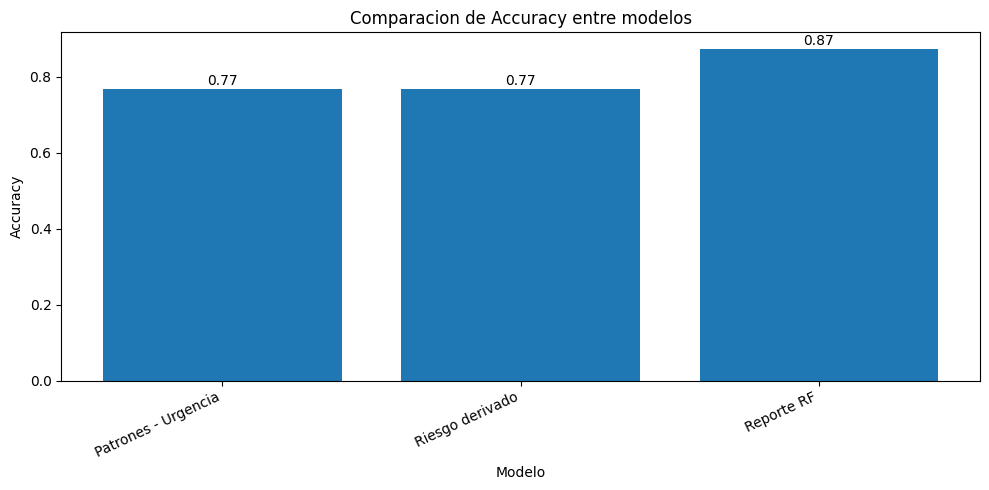

In [42]:
# ==============================================================================
# Gráfica comparativa de accuracy
# ==============================================================================
# Este bloque arma una tabla de métricas resumidas y genera una gráfica de barras comparando
# el accuracy de los modelos principales del estudio.

# Calcula las métricas de un patrón representativo utilizando la etiqueta de urgencia.
pattern_accuracy = accuracy_score(y_true_patterns[:, 0], y_pred_patterns[:, 0])
# Calcula el Macro F1 del patrón representativo.
pattern_macro_f1 = f1_score(y_true_patterns[:, 0], y_pred_patterns[:, 0], average="macro", zero_division=0)
# Calcula el Weighted F1 del patrón representativo.
pattern_weighted_f1 = f1_score(y_true_patterns[:, 0], y_pred_patterns[:, 0], average="weighted", zero_division=0)

# Calcula el accuracy del modelo de riesgo derivado.
risk_accuracy = accuracy_score(y_true_risk, y_pred_risk)
# Calcula el Macro F1 del modelo de riesgo derivado.
risk_macro_f1 = f1_score(y_true_risk, y_pred_risk, average="macro", zero_division=0)
# Calcula el Weighted F1 del modelo de riesgo derivado.
risk_weighted_f1 = f1_score(y_true_risk, y_pred_risk, average="weighted", zero_division=0)

# Calcula el accuracy del modelo final de reporte con Random Forest.
report_rf_accuracy = accuracy_score(y_test_rf, y_pred_report_rf)
# Calcula el Macro F1 del modelo final de reporte con Random Forest.
report_rf_macro_f1 = f1_score(y_test_rf, y_pred_report_rf, average="macro", zero_division=0)
# Calcula el Weighted F1 del modelo final de reporte con Random Forest.
report_rf_weighted_f1 = f1_score(y_test_rf, y_pred_report_rf, average="weighted", zero_division=0)

# Crea o actualiza un DataFrame que será utilizado en la siguiente etapa del flujo.
df_model_metrics = pd.DataFrame({
    "modelo": ["Patrones - Urgencia", "Riesgo derivado", "Reporte RF"],
    "accuracy": [pattern_accuracy, risk_accuracy, report_rf_accuracy],
    "macro_f1": [pattern_macro_f1, risk_macro_f1, report_rf_macro_f1],
    "weighted_f1": [pattern_weighted_f1, risk_weighted_f1, report_rf_weighted_f1]
})

# Muestra la tabla resumida de métricas para dejar evidencia reproducible.
print(df_model_metrics)

# Crea una nueva figura de matplotlib para la visualización.
plt.figure(figsize=(10, 5))
# Dibuja el elemento principal de la gráfica según el tipo de visualización requerido.
plt.bar(df_model_metrics["modelo"], df_model_metrics["accuracy"])
# Configura metadatos de la gráfica para hacerla legible e interpretable.
plt.title("Comparacion de Accuracy entre modelos")
# Configura metadatos de la gráfica para hacerla legible e interpretable.
plt.xlabel("Modelo")
# Configura metadatos de la gráfica para hacerla legible e interpretable.
plt.ylabel("Accuracy")
plt.xticks(rotation=25, ha="right")
# Inicia un bucle para recorrer elementos y aplicar una transformación o cálculo repetitivo.
for i, v in enumerate(df_model_metrics["accuracy"]):
    plt.text(i, v + 0.01, f"{v:.2f}", ha="center")
plt.tight_layout()
# Renderiza la figura para mostrarla en la salida de Jupyter.
plt.show()

## Grafica 2. Comparacion de Macro F1 entre modelos

El Macro F1 resulta especialmente util cuando existe desbalance entre clases, ya que evalua el desempeno promedio sin favorecer a la clase mayoritaria.


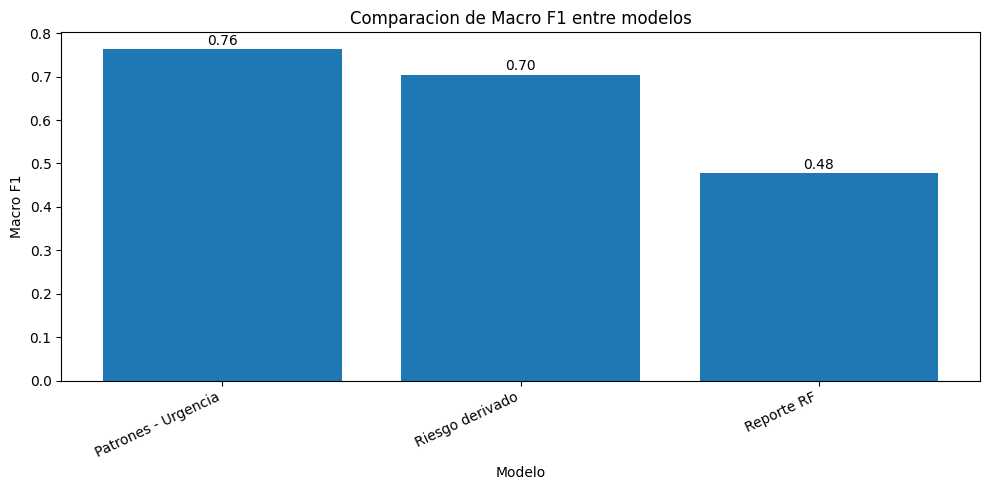

In [43]:
# ==============================================================================
# Gráfica comparativa de Macro F1
# ==============================================================================
# Este bloque visualiza el Macro F1 de los modelos para destacar el desempeño promedio entre
# clases sin favorecer a la clase mayoritaria.

# Crea una nueva figura de matplotlib para la visualización.
plt.figure(figsize=(10, 5))
# Dibuja el elemento principal de la gráfica según el tipo de visualización requerido.
plt.bar(df_model_metrics["modelo"], df_model_metrics["macro_f1"])
# Configura metadatos de la gráfica para hacerla legible e interpretable.
plt.title("Comparacion de Macro F1 entre modelos")
# Configura metadatos de la gráfica para hacerla legible e interpretable.
plt.xlabel("Modelo")
# Configura metadatos de la gráfica para hacerla legible e interpretable.
plt.ylabel("Macro F1")
plt.xticks(rotation=25, ha="right")
# Inicia un bucle para recorrer elementos y aplicar una transformación o cálculo repetitivo.
for i, v in enumerate(df_model_metrics["macro_f1"]):
    plt.text(i, v + 0.01, f"{v:.2f}", ha="center")
plt.tight_layout()
# Renderiza la figura para mostrarla en la salida del notebook.
plt.show()

## Grafica 3. Comparacion de Weighted F1 entre modelos

El Weighted F1 pondera el rendimiento por frecuencia de clase y ayuda a contextualizar el efecto del desbalance sobre los clasificadores.


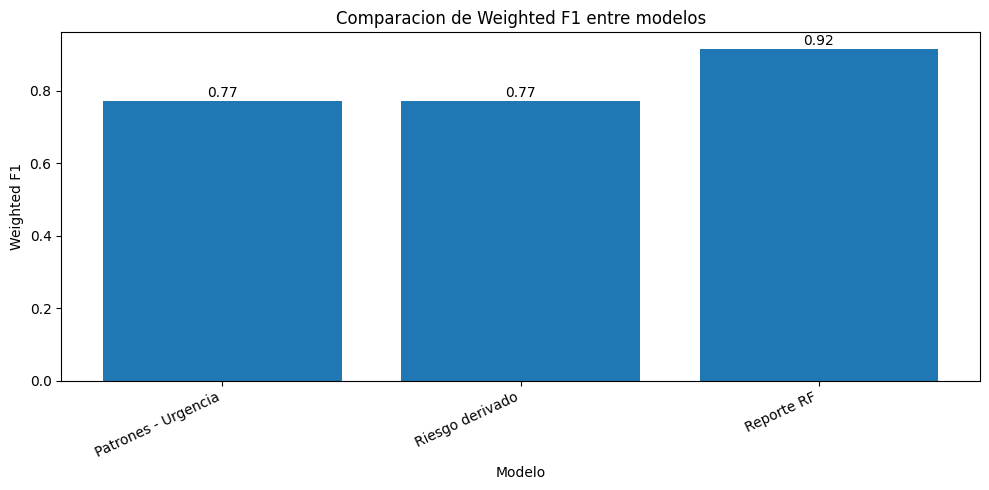

In [44]:
# ==============================================================================
# Gráfica comparativa de Weighted F1
# ==============================================================================
# Este bloque genera una comparación del Weighted F1, útil para observar el desempeño
# ponderado por frecuencia de clase en escenarios desbalanceados.

# Crea una nueva figura de matplotlib para la visualización.
plt.figure(figsize=(10, 5))
# Dibuja el elemento principal de la gráfica según el tipo de visualización requerido.
plt.bar(df_model_metrics["modelo"], df_model_metrics["weighted_f1"])
# Configura metadatos de la gráfica para hacerla legible e interpretable.
plt.title("Comparacion de Weighted F1 entre modelos")
# Configura metadatos de la gráfica para hacerla legible e interpretable.
plt.xlabel("Modelo")
# Configura metadatos de la gráfica para hacerla legible e interpretable.
plt.ylabel("Weighted F1")
plt.xticks(rotation=25, ha="right")
# Inicia un bucle para recorrer elementos y aplicar una transformación o cálculo repetitivo.
for i, v in enumerate(df_model_metrics["weighted_f1"]):
    plt.text(i, v + 0.01, f"{v:.2f}", ha="center")
plt.tight_layout()
# Renderiza la figura para mostrarla en la salida del notebook.
plt.show()

## Grafica 4. Distribucion final de patrones de ingenieria social

Esta figura resume cuantos templates activaron cada patron despues del proceso de depuracion semantica y balanceo de reglas.


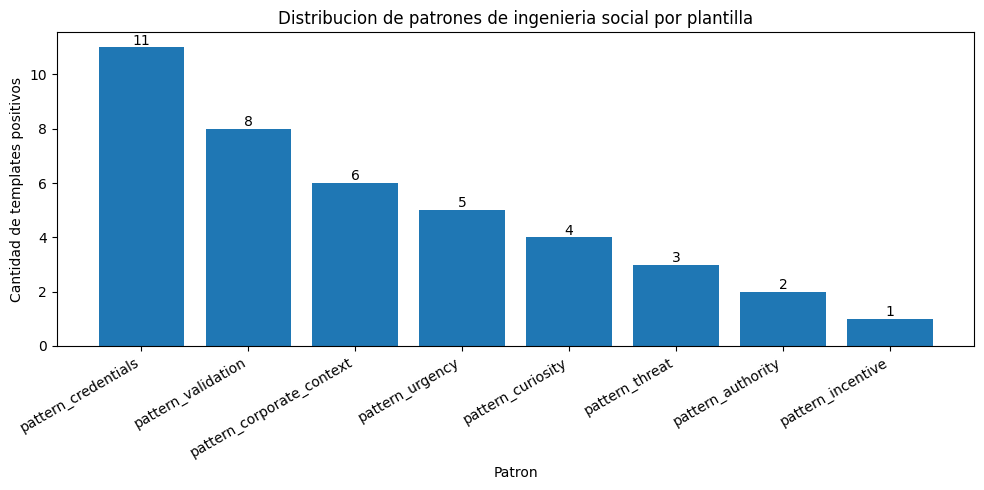

In [45]:
# ==============================================================================
# Distribución de patrones por plantilla
# ==============================================================================
# Este bloque resume cuántas plantillas activaron cada patrón de ingeniería social y lo
# presenta en una gráfica de barras.

pattern_summary = pd.DataFrame({
    "pattern": pattern_cols,
    "positives": [df_templates_final[c].sum() for c in pattern_cols]
}).sort_values("positives", ascending=False)

# Crea una nueva figura de matplotlib para la visualización.
plt.figure(figsize=(10, 5))
# Dibuja el elemento principal de la gráfica según el tipo de visualización requerido.
plt.bar(pattern_summary["pattern"], pattern_summary["positives"])
# Configura metadatos de la gráfica para hacerla legible e interpretable.
plt.title("Distribucion de patrones de ingenieria social por plantilla")
# Configura metadatos de la gráfica para hacerla legible e interpretable.
plt.xlabel("Patron")
# Configura metadatos de la gráfica para hacerla legible e interpretable.
plt.ylabel("Cantidad de templates positivos")
plt.xticks(rotation=30, ha="right")
# Inicia un bucle para recorrer elementos y aplicar una transformación o cálculo repetitivo.
for i, v in enumerate(pattern_summary["positives"]):
    plt.text(i, v + 0.1, f"{int(v)}", ha="center")
plt.tight_layout()
# Renderiza la figura para mostrarla en la salida del notebook.
plt.show()

## Grafica 5. Matriz de confusion del modelo de riesgo derivado

La matriz muestra la capacidad del modelo para discriminar entre riesgo bajo, medio y alto a partir de texto, patrones y banderas tecnicas.


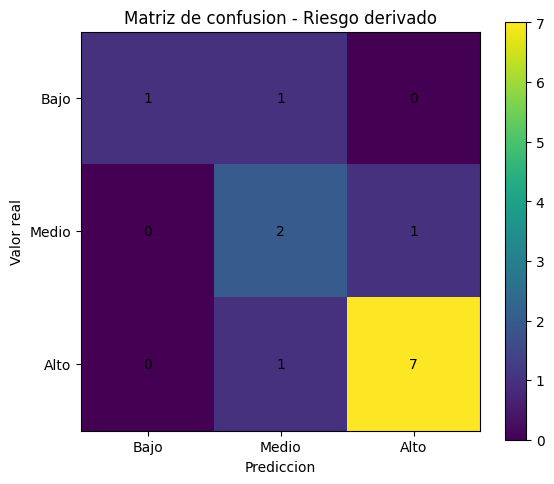

In [46]:
# ==============================================================================
# Matriz de confusión del riesgo
# ==============================================================================
# Este bloque representa visualmente la matriz de confusión del modelo de riesgo derivado.

# Crea una nueva figura de matplotlib para la visualización.
plt.figure(figsize=(6, 5))
# Dibuja el elemento principal de la gráfica según el tipo de visualización requerido.
plt.imshow(cm_risk, interpolation="nearest")
# Configura metadatos de la gráfica para hacerla legible e interpretable.
plt.title("Matriz de confusion - Riesgo derivado")
plt.colorbar()
plt.xticks(np.arange(3), ["Bajo", "Medio", "Alto"])
plt.yticks(np.arange(3), ["Bajo", "Medio", "Alto"])
# Configura metadatos de la gráfica para hacerla legible e interpretable.
plt.xlabel("Prediccion")
# Configura metadatos de la gráfica para hacerla legible e interpretable.
plt.ylabel("Valor real")

# Inicia un bucle para recorrer elementos y aplicar una transformación o cálculo repetitivo.
for i in range(cm_risk.shape[0]):
# Inicia un bucle para recorrer elementos y aplicar una transformación o cálculo repetitivo.
    for j in range(cm_risk.shape[1]):
        plt.text(j, i, str(cm_risk[i, j]), ha="center", va="center")

plt.tight_layout()
# Renderiza la figura para mostrarla en la salida del notebook.
plt.show()

## Grafica 6. Matriz de confusion del modelo de reporte con Random Forest

Esta matriz representa el comportamiento final del mejor modelo obtenido para la tarea de reporte de correos.


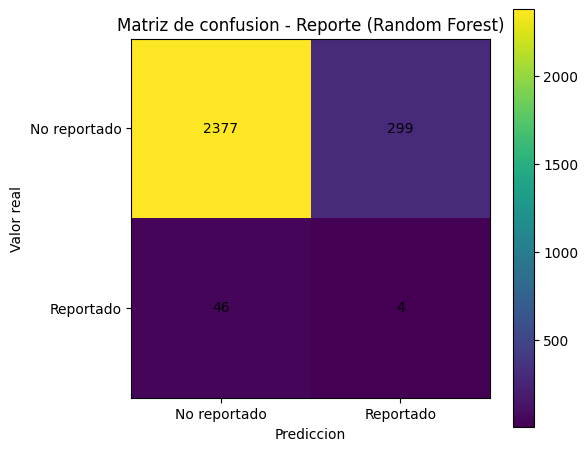

In [47]:
# ==============================================================================
# Matriz de confusión del reporte con Random Forest
# ==============================================================================
# Este bloque representa visualmente la matriz de confusión del mejor modelo final de
# reporte.

# Crea una nueva figura de matplotlib para la visualización.
plt.figure(figsize=(6, 5))
# Dibuja el elemento principal de la gráfica según el tipo de visualización requerido.
plt.imshow(cm_report_rf, interpolation="nearest")
# Configura metadatos de la gráfica para hacerla legible e interpretable.
plt.title("Matriz de confusion - Reporte (Random Forest)")
plt.colorbar()
plt.xticks(np.arange(2), ["No reportado", "Reportado"])
plt.yticks(np.arange(2), ["No reportado", "Reportado"])
# Configura metadatos de la gráfica para hacerla legible e interpretable.
plt.xlabel("Prediccion")
# Configura metadatos de la gráfica para hacerla legible e interpretable.
plt.ylabel("Valor real")

# Inicia un bucle para recorrer elementos y aplicar una transformación o cálculo repetitivo.
for i in range(cm_report_rf.shape[0]):
# Inicia un bucle para recorrer elementos y aplicar una transformación o cálculo repetitivo.
    for j in range(cm_report_rf.shape[1]):
        plt.text(j, i, str(cm_report_rf[i, j]), ha="center", va="center")

plt.tight_layout()
# Renderiza la figura para mostrarla en la salida del notebook.
plt.show()

## Grafica 7. Analisis de thresholds en el modelo lineal de reporte

Esta curva compara el efecto de diferentes umbrales sobre accuracy, precision, recall y F1 de la clase reportada, permitiendo evaluar la calibracion del clasificador.


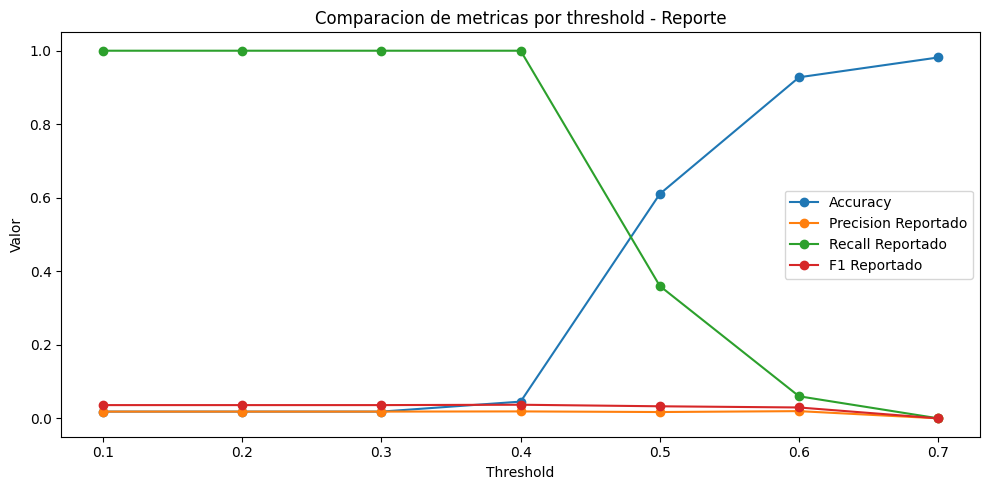

In [48]:
# ==============================================================================
# Comparación de métricas por threshold
# ==============================================================================
# Este bloque grafica cómo cambian accuracy, precision, recall y F1 al modificar el umbral
# del modelo lineal de reporte.

# Crea una nueva figura de matplotlib para la visualización.
plt.figure(figsize=(10, 5))
# Dibuja el elemento principal de la gráfica según el tipo de visualización requerido.
plt.plot(df_thresholds["threshold"], df_thresholds["accuracy"], marker="o", label="Accuracy")
# Dibuja el elemento principal de la gráfica según el tipo de visualización requerido.
plt.plot(df_thresholds["threshold"], df_thresholds["precision_reported"], marker="o", label="Precision Reportado")
# Dibuja el elemento principal de la gráfica según el tipo de visualización requerido.
plt.plot(df_thresholds["threshold"], df_thresholds["recall_reported"], marker="o", label="Recall Reportado")
# Dibuja el elemento principal de la gráfica según el tipo de visualización requerido.
plt.plot(df_thresholds["threshold"], df_thresholds["f1_reported"], marker="o", label="F1 Reportado")
# Configura metadatos de la gráfica para hacerla legible e interpretable.
plt.title("Comparacion de metricas por threshold - Reporte")
# Configura metadatos de la gráfica para hacerla legible e interpretable.
plt.xlabel("Threshold")
# Configura metadatos de la gráfica para hacerla legible e interpretable.
plt.ylabel("Valor")
plt.legend()
plt.tight_layout()
# Renderiza la figura para mostrarla en la salida del notebook.
plt.show()

## Grafica 8. Distribucion del riesgo derivado por plantilla

Esta figura resume la cantidad de plantillas clasificadas en riesgo bajo, medio y alto segun la puntuacion derivada definida en el cuaderno.


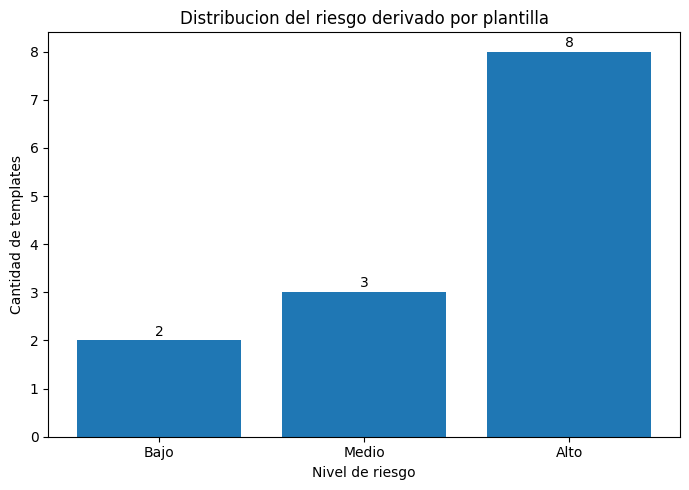

In [49]:
# ==============================================================================
# Distribución del riesgo derivado
# ==============================================================================
# Este bloque resume la cantidad de plantillas clasificadas en Bajo, Medio y Alto según el
# riesgo derivado.

risk_dist = (
    df_risk_rules["risk_label_rule"]
    .value_counts()
    .reindex(["Bajo", "Medio", "Alto"], fill_value=0)
)

# Crea una nueva figura de matplotlib para la visualización.
plt.figure(figsize=(7, 5))
# Dibuja el elemento principal de la gráfica según el tipo de visualización requerido.
plt.bar(risk_dist.index, risk_dist.values)
# Configura metadatos de la gráfica para hacerla legible e interpretable.
plt.title("Distribucion del riesgo derivado por plantilla")
# Configura metadatos de la gráfica para hacerla legible e interpretable.
plt.xlabel("Nivel de riesgo")
# Configura metadatos de la gráfica para hacerla legible e interpretable.
plt.ylabel("Cantidad de templates")
# Inicia un bucle para recorrer elementos y aplicar una transformación o cálculo repetitivo.
for i, v in enumerate(risk_dist.values):
    plt.text(i, v + 0.1, str(int(v)), ha="center")
plt.tight_layout()
# Renderiza la figura para mostrarla en la salida del notebook.
plt.show()

## Grafica 9. Tasa de reporte observada por plantilla

La ultima visualizacion permite contrastar la frecuencia empirica de reporte por `template_id`, lo que ayuda a contextualizar la dificultad del problema conductual.


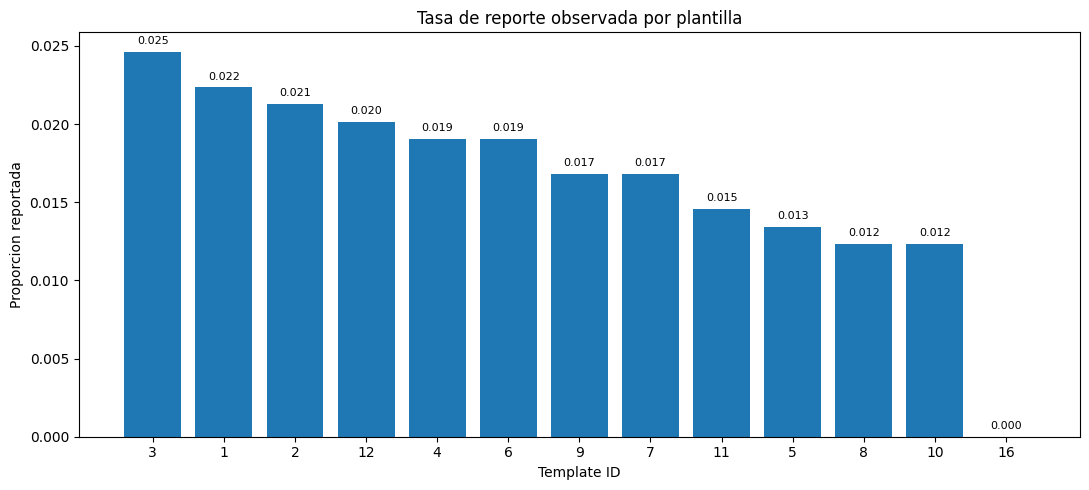

In [50]:
# ==============================================================================
# Tasa de reporte por plantilla
# ==============================================================================
# Este bloque calcula y grafica la proporción observada de reportes por `template_id`,
# permitiendo comparar el comportamiento empírico entre plantillas.

# Crea o actualiza un DataFrame que será utilizado en la siguiente etapa del flujo.
df_report_by_template = (
# Crea o actualiza un DataFrame que será utilizado en la siguiente etapa del flujo.
    df_report_result.groupby(["template_id", "template_subject"], as_index=False)["reported_target"]
    .mean()
    .rename(columns={"reported_target": "reported_rate"})
    .sort_values("reported_rate", ascending=False)
)

# Crea una nueva figura de matplotlib para la visualización.
plt.figure(figsize=(11, 5))
# Normaliza o convierte el tipo de los datos para asegurar consistencia en el análisis.
plt.bar(df_report_by_template["template_id"].astype(str), df_report_by_template["reported_rate"])
# Configura metadatos de la gráfica para hacerla legible e interpretable.
plt.title("Tasa de reporte observada por plantilla")
# Configura metadatos de la gráfica para hacerla legible e interpretable.
plt.xlabel("Template ID")
# Configura metadatos de la gráfica para hacerla legible e interpretable.
plt.ylabel("Proporcion reportada")
# Inicia un bucle para recorrer elementos y aplicar una transformación o cálculo repetitivo.
for i, v in enumerate(df_report_by_template["reported_rate"]):
    plt.text(i, v + 0.0005, f"{v:.3f}", ha="center", fontsize=8)
plt.tight_layout()
# Renderiza la figura para mostrarla en la salida del notebook.
plt.show()

# Graficas conceptuales de los algoritmos utilizados realmente en el proyecto

Las siguientes figuras corresponden exclusivamente a algoritmos de aprendizaje supervisado que sí fueron utilizados en el flujo analítico final.  
A diferencia de la versión anterior, aquí no se incluye regresión lineal, ya que no formó parte de los modelos reales del proyecto.

Las visualizaciones se construyen con información real producida por el notebook, de modo que cada figura refleja cómo se comportaron los modelos sobre los datos trabajados:
- regresión logística binaria para reporte,
- OneVsRest + regresión logística para patrones multietiqueta,
- regresión logística multiclase para riesgo,
- Random Forest para reporte.


## Grafica 10. Regresión logística binaria aplicada al reporte de correos

Esta visualización usa las probabilidades reales estimadas por el modelo lineal de reporte para la clase positiva (`reported_target = 1`).  
El objetivo es mostrar cómo la regresión logística distribuyó su confianza sobre los correos evaluados y por qué la calibración del umbral fue una etapa necesaria dentro del análisis.


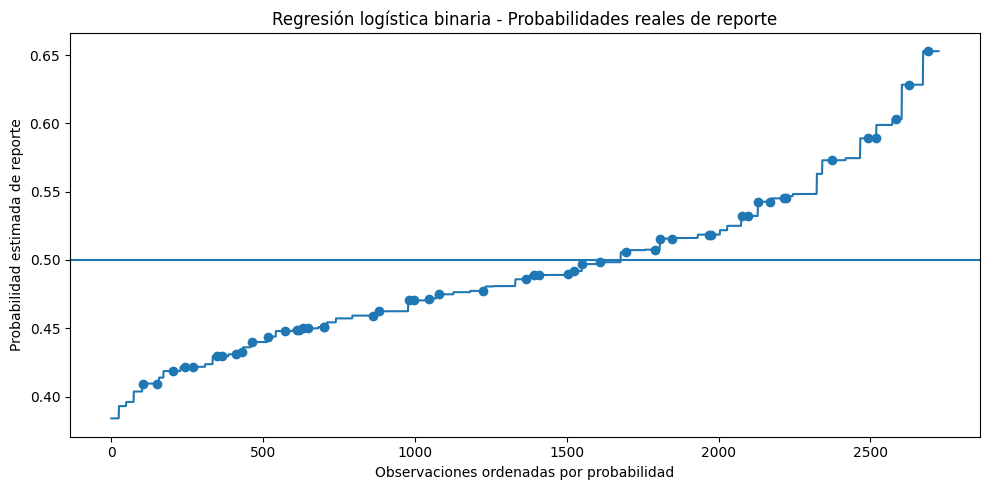

In [51]:
# ==============================================================================
# Regresión logística binaria para reporte - probabilidades reales estimadas
# ==============================================================================
# Este bloque toma las probabilidades reales generadas por el modelo de regresión
# logística para la clase positiva y las ordena para observar su comportamiento
# sobre el conjunto de prueba.
#
# Se usa información real del proyecto:
# - y_prob_report: probabilidad estimada de reporte
# - y_test: clase real observada en el conjunto de evaluación

# Convierte las estructuras a arreglos numéricos para asegurar consistencia.
y_prob_report_arr = np.asarray(y_prob_report, dtype=float)
y_test_arr = np.asarray(y_test, dtype=int)

# Ordena las probabilidades de menor a mayor para facilitar la lectura visual.
order_prob = np.argsort(y_prob_report_arr)
y_prob_sorted = y_prob_report_arr[order_prob]
y_test_sorted = y_test_arr[order_prob]

# Crea una nueva figura de matplotlib para la visualización.
plt.figure(figsize=(10, 5))
# Dibuja la curva de probabilidades ordenadas generadas por la regresión logística.
plt.plot(range(len(y_prob_sorted)), y_prob_sorted)
# Señala el umbral de decisión clásico de 0.5 usado en clasificación binaria.
plt.axhline(0.5)
# Superpone los casos reales reportados para mostrar dónde cae la clase positiva.
positive_idx = np.where(y_test_sorted == 1)[0]
plt.scatter(positive_idx, y_prob_sorted[positive_idx])

# Coloca título y etiquetas descriptivas.
plt.title("Regresión logística binaria - Probabilidades reales de reporte")
plt.xlabel("Observaciones ordenadas por probabilidad")
plt.ylabel("Probabilidad estimada de reporte")
plt.tight_layout()
plt.show()

## Grafica 11. OneVsRest + regresión logística para patrones de ingeniería social

Esta figura resume el rendimiento por etiqueta del clasificador multietiqueta utilizado para detectar patrones de ingeniería social.  
Cada barra representa el desempeño obtenido con datos reales de validación Leave-One-Out, mostrando cuáles patrones ofrecieron una señal más estable para el modelo.


                     pattern  macro_f1  accuracy
0            pattern_urgency  0.763636  0.769231
7  pattern_corporate_context  0.763636  0.769231
5          pattern_incentive  0.480000  0.923077
1          pattern_authority  0.458333  0.846154
2        pattern_credentials  0.458333  0.846154
3             pattern_threat  0.434783  0.769231
4         pattern_validation  0.380952  0.615385
6          pattern_curiosity  0.380952  0.615385


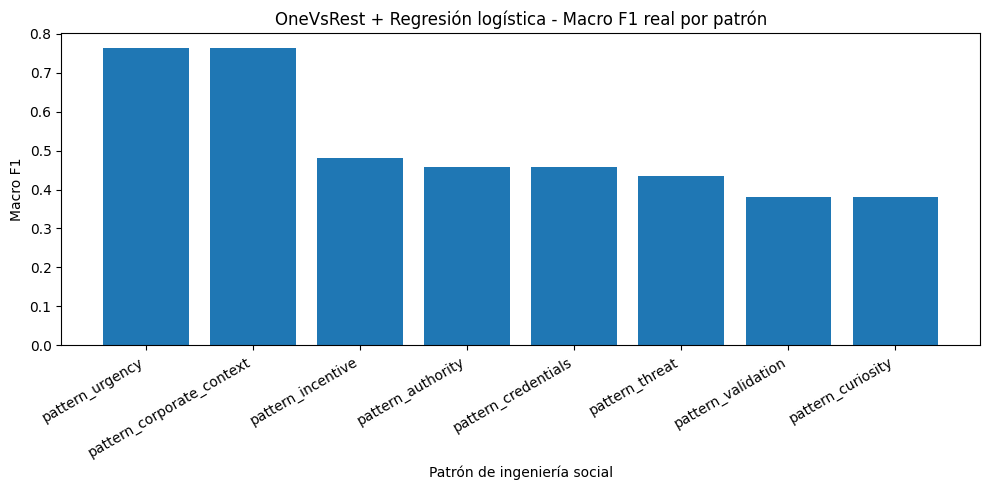

In [52]:
# ==============================================================================
# OneVsRest + regresión logística - desempeño real por patrón
# ==============================================================================
# Este bloque calcula métricas reales por etiqueta usando las salidas del modelo
# multietiqueta ya evaluado previamente:
# - y_true_patterns: valores reales por patrón
# - y_pred_patterns: valores predichos por patrón
#
# El propósito es mostrar, de manera conceptual pero basada en resultados reales,
# cómo respondió el enfoque OneVsRest + regresión logística en cada etiqueta.

pattern_f1_scores = []
pattern_accuracy_scores = []

# Recorre cada patrón para calcular métricas individuales.
for i, col in enumerate(pattern_cols):
    f1_val = f1_score(y_true_patterns[:, i], y_pred_patterns[:, i], average="macro", zero_division=0)
    acc_val = accuracy_score(y_true_patterns[:, i], y_pred_patterns[:, i])

    pattern_f1_scores.append(f1_val)
    pattern_accuracy_scores.append(acc_val)

# Construye un DataFrame resumen para documentar el rendimiento por etiqueta.
df_pattern_model_metrics = pd.DataFrame({
    "pattern": pattern_cols,
    "macro_f1": pattern_f1_scores,
    "accuracy": pattern_accuracy_scores
}).sort_values("macro_f1", ascending=False)

# Muestra la tabla resumen como evidencia adicional del cálculo.
print(df_pattern_model_metrics)

# Crea una nueva figura de matplotlib para la visualización.
plt.figure(figsize=(10, 5))
# Dibuja barras con el Macro F1 real por patrón.
plt.bar(df_pattern_model_metrics["pattern"], df_pattern_model_metrics["macro_f1"])

# Añade título y etiquetas.
plt.title("OneVsRest + Regresión logística - Macro F1 real por patrón")
plt.xlabel("Patrón de ingeniería social")
plt.ylabel("Macro F1")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Grafica 12. Regresión logística multiclase aplicada al riesgo derivado

Esta visualización usa los coeficientes reales del modelo multiclase de riesgo para mostrar qué variables estructuradas tuvieron mayor peso absoluto dentro de la clasificación.  
La figura ayuda a interpretar qué señales del correo influyeron con mayor intensidad en la estimación de riesgo.


      class                         feature      coef  abs_coef
2542  Medio          num__pattern_curiosity  0.774465  0.774465
1258   Bajo        num__pattern_credentials -0.639996  0.639996
3823   Alto  num__pattern_corporate_context  0.600228  0.600228
1261   Bajo          num__pattern_incentive  0.498350  0.498350
3819   Alto             num__pattern_threat  0.487695  0.487695
3820   Alto         num__pattern_validation  0.419321  0.419321
3822   Alto          num__pattern_curiosity -0.406352  0.406352
1260   Bajo         num__pattern_validation -0.387447  0.387447
2539  Medio             num__pattern_threat -0.378256  0.378256
1262   Bajo          num__pattern_curiosity -0.368113  0.368113
2543  Medio  num__pattern_corporate_context -0.367790  0.367790
3818   Alto        num__pattern_credentials  0.326720  0.326720
2538  Medio        num__pattern_credentials  0.313275  0.313275
1256   Bajo            num__pattern_urgency -0.312280  0.312280
3821   Alto          num__pattern_incent

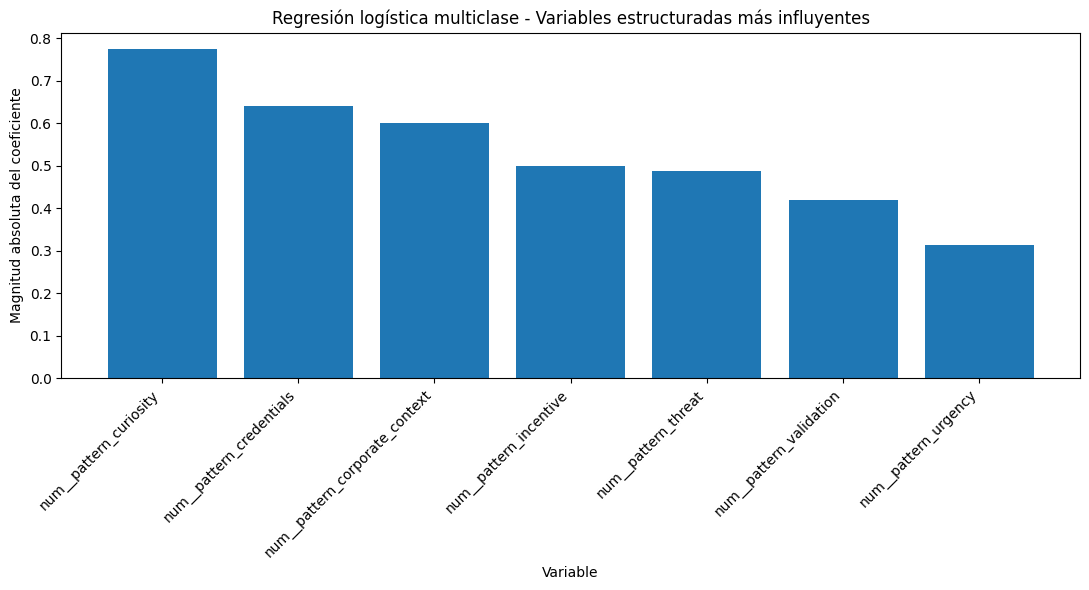

In [53]:
# ==============================================================================
# Regresión logística multiclase para riesgo - variables estructuradas más influyentes
# ==============================================================================
# Este bloque utiliza los coeficientes reales del modelo final de riesgo ya entrenado
# sobre todo el conjunto disponible.
#
# Se filtran solamente variables estructuradas:
# - numéricas (banderas y patrones)
# - categóricas codificadas
#
# El objetivo es ofrecer una vista conceptual del modelo, basada en información real
# de entrenamiento, resaltando qué variables tuvieron mayor peso absoluto.

# Reconstruye un DataFrame con coeficientes y nombres de características por clase.
df_risk_coef_all = []

for class_idx, class_label in class_map.items():
    temp = pd.DataFrame({
        "class": class_label,
        "feature": feature_names_risk,
        "coef": coef_matrix_risk[class_idx],
        "abs_coef": np.abs(coef_matrix_risk[class_idx])
    })
    df_risk_coef_all.append(temp)

df_risk_coef_all = pd.concat(df_risk_coef_all, ignore_index=True)

# Filtra únicamente variables estructuradas para evitar saturar la visualización con texto TF-IDF.
df_risk_structured = df_risk_coef_all[
    df_risk_coef_all["feature"].str.contains("num__|cat__", regex=True)
].copy()

# Selecciona las variables con mayor peso absoluto global.
df_risk_structured_top = (
    df_risk_structured
    .sort_values("abs_coef", ascending=False)
    .head(15)
)

# Muestra la tabla resultante como respaldo del cálculo.
print(df_risk_structured_top[["class", "feature", "coef", "abs_coef"]])

# Crea una nueva figura de matplotlib para la visualización.
plt.figure(figsize=(11, 6))
# Dibuja barras con las variables estructuradas más influyentes del modelo de riesgo.
plt.bar(df_risk_structured_top["feature"], df_risk_structured_top["abs_coef"])

# Añade título y etiquetas.
plt.title("Regresión logística multiclase - Variables estructuradas más influyentes")
plt.xlabel("Variable")
plt.ylabel("Magnitud absoluta del coeficiente")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Grafica 13. Random Forest para la predicción de reporte

Esta visualización mantiene la importancia de variables del modelo final de bosques aleatorios.  
A diferencia de una representación abstracta de votación entre árboles, aquí se usa directamente la importancia real calculada por el modelo entrenado con las variables estructuradas del proyecto.


                                      feature  importance
3                             num__risk_score    0.069465
27          cat__result_status_Submitted Data    0.062684
26            cat__result_status_Clicked Link    0.060152
20               cat__position_Jefe de Taller    0.059986
18         cat__position_Encargado de Compras    0.053955
15        cat__position_Asistente de Finanzas    0.052851
13             cat__position_Analista de RRHH    0.051774
24  cat__position_Supervisor de Mantenimiento    0.050544
25           cat__position_Tecnico de Soporte    0.045138
14             cat__position_Asesor Comercial    0.045003
23                cat__position_Recepcionista    0.044873
22         cat__position_Operador de Sistemas    0.043893
16            cat__position_Auxiliar Contable    0.043335
19           cat__position_Jefe de Produccion    0.043222
17        cat__position_Coordinador Logistico    0.042121


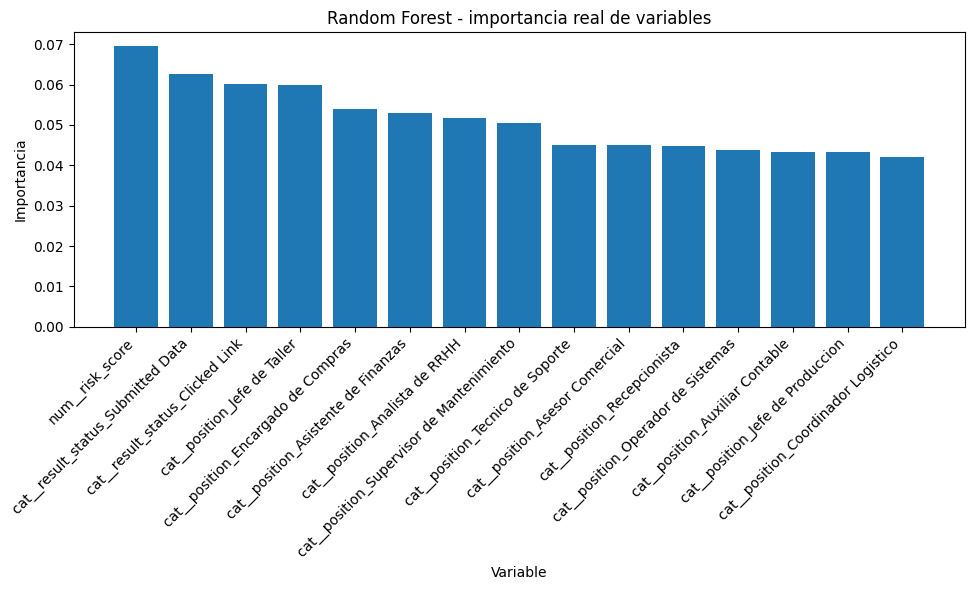

In [54]:
# ==============================================================================
# Random Forest - importancia real de variables para la tarea de reporte
# ==============================================================================
# Este bloque extrae las importancias reales del modelo Random Forest final y grafica
# las variables con mayor peso relativo dentro de la predicción de reporte.
#
# La figura refleja información efectiva del modelo entrenado, por lo que resulta más
# útil que una representación puramente conceptual de árboles votando.

prep_rf = model_report_rf.named_steps["prep"]
clf_rf = model_report_rf.named_steps["clf"]

feature_names_rf = prep_rf.get_feature_names_out()
importances_rf = clf_rf.feature_importances_

# Construye un DataFrame de importancias ordenado de mayor a menor.
df_rf_imp = pd.DataFrame({
    "feature": feature_names_rf,
    "importance": importances_rf
}).sort_values("importance", ascending=False).head(15)

# Muestra la tabla como evidencia adicional.
print(df_rf_imp)

# Crea una nueva figura de matplotlib para la visualización.
plt.figure(figsize=(10, 6))
# Dibuja la importancia relativa de las variables más influyentes.
plt.bar(df_rf_imp["feature"], df_rf_imp["importance"])

# Añade título y etiquetas.
plt.title("Random Forest - importancia real de variables")
plt.xlabel("Variable")
plt.ylabel("Importancia")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Analisis final de resultados

## Sintesis interpretativa

Los resultados del cuaderno muestran tres hallazgos principales.  
En primer lugar, la deteccion de patrones de ingenieria social evidencio que ciertas categorias, especialmente urgencia, curiosidad, validacion y contexto corporativo, presentan una estructura linguistica lo suficientemente consistente como para ser identificada mediante representaciones TF-IDF y clasificadores supervisados. Esto confirma que el contenido textual de las plantillas contiene señales semanticas aprovechables para la caracterizacion automatizada del ataque.

En segundo lugar, la estimacion del riesgo mostro un mejor comportamiento que la prediccion del reporte. La construccion del riesgo derivado permitio introducir variabilidad en la variable objetivo, superando la limitacion del riesgo original casi constante. A partir de ello, el clasificador logro una discriminacion aceptable, particularmente en la clase de riesgo alto, lo que sugiere que la combinacion entre patrones de ingenieria social, terminos del mensaje y banderas tecnicas constituye una base util para la priorizacion analitica de correos sospechosos.

En tercer lugar, la prediccion del reporte resulto ser la tarea mas compleja del estudio. Aunque se observaron señales utiles, tanto el modelo lineal como el modelo basado en bosques aleatorios presentaron limitaciones para recuperar la clase positiva con precision suficiente. Este comportamiento es coherente con la naturaleza del fenomeno: reportar o no reportar un correo no depende exclusivamente del contenido del mensaje, sino tambien de factores humanos y contextuales que no estaban completamente representados en el conjunto de variables disponible.

## Hallazgos tecnicos relevantes

1. La estructura textual de los correos permite caracterizar patrones de ingenieria social con un nivel de desempeno razonable cuando las etiquetas cuentan con distribuciones minimamente utilizables.
2. El riesgo puede modelarse con mayor estabilidad que el reporte, debido a que su definicion puede apoyarse en senales textuales y tecnicas mas directamente observables.
3. El fuerte desbalance de clases afecta de manera considerable la prediccion del reporte, reduciendo la precision de la clase minoritaria aun cuando se aplican pesos balanceados o modelos no lineales.
4. La cantidad reducida de plantillas unicas condiciona la capacidad de generalizacion de los modelos y obliga a utilizar esquemas de validacion cuidadosamente seleccionados, como Leave-One-Out y GroupShuffleSplit por template_id.

## Relacion con los objetivos del estudio

Los resultados obtenidos permiten afirmar que el objetivo de identificar y caracterizar patrones de ingenieria social fue alcanzado de manera satisfactoria en una fase experimental. Asimismo, se demostro que dichas caracteristicas pueden integrarse con variables estructuradas para estimar el nivel de riesgo del correo. Finalmente, aunque la prediccion del reporte no alcanzo el mismo nivel de desempeno, el ejercicio permitio evidenciar su mayor complejidad y establecer una base metodologica clara para estudios futuros.



# Limitaciones del estudio

El presente analisis debe interpretarse a la luz de varias limitaciones metodologicas y operativas.

## Limitaciones del conjunto de datos

La primera limitacion corresponde al numero reducido de plantillas unicas disponibles para el modelado textual. Aunque el dataset a nivel de resultados contiene miles de registros, gran parte de ellos derivan de un numero pequeno de plantillas base, lo cual restringe la diversidad linguistica efectiva y aumenta el riesgo de sobreajuste en modelos de texto.

La segunda limitacion es el desbalance de clases. Este problema fue especialmente visible en la variable de reporte, donde los correos efectivamente reportados representaron una fraccion muy pequena del total. Bajo estas condiciones, metricas globales como accuracy pueden resultar enganosas y es necesario interpretar con mayor peso precision, recall, F1 y matrices de confusion.

La tercera limitacion se relaciona con la construccion de etiquetas. Tanto los patrones de ingenieria social como el riesgo derivado fueron definidos, en parte, mediante reglas semiautomaticas. Aunque este procedimiento es valido como estrategia experimental y de arranque, implica que el sistema aprende sobre categorias que inicialmente fueron inducidas por criterios expertos y no exclusivamente por observaciones humanas independientes.

## Limitaciones del modelado

La prediccion del reporte evidencio que ciertas decisiones del usuario probablemente dependen de variables no observadas en el dataset, tales como nivel de capacitacion, experiencia previa, fatiga, contexto operativo, perfil de riesgo individual o cultura organizacional. En consecuencia, el contenido del mensaje por si solo no basta para explicar completamente la conducta de reporte.

Adicionalmente, el tamano del conjunto obligo a utilizar validaciones conservadoras como Leave-One-Out, adecuadas para el escenario disponible, pero insuficientes para sustituir experimentos de mayor escala con una coleccion mas amplia y heterogenea de plantillas y usuarios.


# Conclusiones

1. Se confirmo que el contenido textual de los correos de phishing contiene patrones identificables de ingenieria social, especialmente en dimensiones como urgencia, validacion, curiosidad y contexto corporativo.
2. La representacion TF-IDF combinada con clasificadores supervisados demostro ser util para la caracterizacion automatizada del contenido de las plantillas.
3. La estimacion del riesgo mostro mayor estabilidad y capacidad discriminativa que la prediccion del reporte, especialmente en la identificacion de correos de riesgo alto.
4. La tarea de reporte se confirmo como el componente mas complejo del problema, debido al fuerte desbalance de clases y a la intervencion de factores conductuales no observados.
5. La metodologia aplicada constituye una base experimental valida para el estudio academico del phishing, aun cuando la generalizacion futura depende de ampliar la variedad de plantillas, mejorar el balance de clases e incorporar variables de comportamiento humano.

# Recomendaciones tecnicas

1. Ampliar el numero de plantillas unicas para mejorar la diversidad textual y la robustez de los modelos de clasificacion.
2. Incorporar variables adicionales relacionadas con el usuario, como cargo, historial de interaccion, nivel de capacitacion o indicadores de comportamiento, para fortalecer la prediccion del reporte.
3. Recolectar mas ejemplos de clases minoritarias, especialmente correos reportados y plantillas de bajo riesgo, a fin de reducir el impacto del desbalance.
4. Evaluar modelos adicionales orientados a clases desbalanceadas, como tecnicas de remuestreo, ensamblados especializados o calibracion probabilistica avanzada.
5. Mantener separados los niveles de analisis por plantilla y por resultado individual, ya que ambos responden a preguntas distintas dentro del problema de phishing.
6. Complementar el etiquetado semiautomatico con validacion experta humana para fortalecer la validez externa de los patrones definidos.

# Cierre academico

En conjunto, el ejercicio demuestra que el analisis de datos y el aprendizaje supervisado pueden aportar valor en la deteccion y caracterizacion de patrones de ingenieria social en correos de phishing. Aunque existen restricciones asociadas al tamano y distribucion del dataset, los resultados obtenidos ofrecen evidencia suficiente para sostener la viabilidad tecnica de la propuesta y sirven como fundamento para una evolucion posterior hacia escenarios mas amplios, balanceados y cercanos a entornos organizacionales reales.


# Evidencia final y cierre técnico

Los siguientes bloques completan el cierre operativo del proyecto.  
Su propósito es exportar datasets, tablas, métricas, gráficas y modelos finales para dejar evidencia reproducible del experimento, y generar un resumen automático de hallazgos para la memoria técnica o la defensa.


## Exportación de datasets, métricas, tablas, gráficas y modelos

Este bloque crea una carpeta de salida y guarda los artefactos principales del proyecto:
- datasets finales,
- tablas de comparación,
- matrices de confusión,
- métricas agregadas,
- modelos serializados,
- y gráficas clave en formato PNG.


In [55]:
# ==============================================================================
# Exportación final de evidencias del proyecto
# ==============================================================================
# Este bloque guarda en disco los datasets finales, tablas de métricas, matrices de
# confusión, modelos serializados y gráficas principales. La idea es dejar una evidencia
# reproducible y reutilizable del análisis final.

# Define la carpeta donde se almacenarán los archivos de salida del proyecto.
output_dir = os.path.join(os.getcwd(), "exportables_finales_proyecto")
# Crea la carpeta de salida si todavía no existe.
os.makedirs(output_dir, exist_ok=True)

# -------------------------
# Exportación de datasets finales
# -------------------------
# Guarda el dataset final de plantillas y patrones de ingeniería social.
df_templates_final.to_csv(os.path.join(output_dir, "df_templates_final.csv"), index=False, encoding="utf-8-sig")
# Guarda el dataset final del riesgo derivado por plantilla.
df_risk_rules.to_csv(os.path.join(output_dir, "df_risk_rules.csv"), index=False, encoding="utf-8-sig")
# Guarda el dataset final de resultados para la tarea de reporte.
df_report_result.to_csv(os.path.join(output_dir, "df_report_result.csv"), index=False, encoding="utf-8-sig")

# -------------------------
# Exportación de tablas auxiliares
# -------------------------
# Guarda la tabla comparativa de métricas entre modelos.
df_model_metrics.to_csv(os.path.join(output_dir, "df_model_metrics.csv"), index=False, encoding="utf-8-sig")
# Guarda la tabla de thresholds del modelo lineal de reporte.
df_thresholds.to_csv(os.path.join(output_dir, "df_thresholds.csv"), index=False, encoding="utf-8-sig")
# Guarda la tabla de importancia de variables de Random Forest.
df_rf_imp.to_csv(os.path.join(output_dir, "df_rf_importance.csv"), index=False, encoding="utf-8-sig")

# Guarda la comparación real vs predicho por template en patrones, si existe.
if "df_compare_templates" in globals():
    df_compare_templates.to_csv(os.path.join(output_dir, "df_compare_templates.csv"), index=False, encoding="utf-8-sig")

# -------------------------
# Exportación de matrices de confusión
# -------------------------
# Convierte y guarda la matriz de confusión del riesgo derivado.
df_cm_risk_export = pd.DataFrame(
    cm_risk,
    index=["Real_Bajo", "Real_Medio", "Real_Alto"],
    columns=["Pred_Bajo", "Pred_Medio", "Pred_Alto"]
)
df_cm_risk_export.to_csv(os.path.join(output_dir, "df_cm_risk.csv"), encoding="utf-8-sig")

# Convierte y guarda la matriz de confusión del reporte con Random Forest.
df_cm_report_rf_export = pd.DataFrame(
    cm_report_rf,
    index=["Real_NoReportado", "Real_Reportado"],
    columns=["Pred_NoReportado", "Pred_Reportado"]
)
df_cm_report_rf_export.to_csv(os.path.join(output_dir, "df_cm_report_rf.csv"), encoding="utf-8-sig")

# -------------------------
# Exportación de métricas resumidas en JSON
# -------------------------
# Arma un diccionario compacto con métricas finales para reutilización externa.
final_metrics = {
    "patterns_urgency": {
        "accuracy": float(pattern_accuracy),
        "macro_f1": float(pattern_macro_f1),
        "weighted_f1": float(pattern_weighted_f1)
    },
    "risk_rule": {
        "accuracy": float(risk_accuracy),
        "macro_f1": float(risk_macro_f1),
        "weighted_f1": float(risk_weighted_f1)
    },
    "report_random_forest": {
        "accuracy": float(report_rf_accuracy),
        "macro_f1": float(report_rf_macro_f1),
        "weighted_f1": float(report_rf_weighted_f1)
    }
}

# Guarda el resumen de métricas en formato JSON.
with open(os.path.join(output_dir, "final_metrics.json"), "w", encoding="utf-8") as f:
    json.dump(final_metrics, f, ensure_ascii=False, indent=4)

# -------------------------
# Serialización de modelos finales
# -------------------------
# Guarda el modelo multietiqueta de patrones.
if "model_patterns_final" in globals():
    joblib.dump(model_patterns_final, os.path.join(output_dir, "model_patterns_final.joblib"))

# Guarda el modelo final de riesgo interpretado.
if "model_risk_final" in globals():
    joblib.dump(model_risk_final, os.path.join(output_dir, "model_risk_final.joblib"))

# Guarda el modelo final de reporte con Random Forest.
if "model_report_rf" in globals():
    joblib.dump(model_report_rf, os.path.join(output_dir, "model_report_rf.joblib"))

# -------------------------
# Exportación de gráficas principales
# -------------------------
# Gráfica de accuracy entre modelos.
plt.figure(figsize=(10, 5))
plt.bar(df_model_metrics["modelo"], df_model_metrics["accuracy"])
plt.title("Comparacion de Accuracy entre modelos")
plt.xlabel("Modelo")
plt.ylabel("Accuracy")
plt.xticks(rotation=25, ha="right")
for i, v in enumerate(df_model_metrics["accuracy"]):
    plt.text(i, v + 0.01, f"{v:.2f}", ha="center")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "grafica_accuracy_modelos.png"), dpi=300, bbox_inches="tight")
plt.close()

# Gráfica de Macro F1 entre modelos.
plt.figure(figsize=(10, 5))
plt.bar(df_model_metrics["modelo"], df_model_metrics["macro_f1"])
plt.title("Comparacion de Macro F1 entre modelos")
plt.xlabel("Modelo")
plt.ylabel("Macro F1")
plt.xticks(rotation=25, ha="right")
for i, v in enumerate(df_model_metrics["macro_f1"]):
    plt.text(i, v + 0.01, f"{v:.2f}", ha="center")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "grafica_macro_f1_modelos.png"), dpi=300, bbox_inches="tight")
plt.close()

# Gráfica de Weighted F1 entre modelos.
plt.figure(figsize=(10, 5))
plt.bar(df_model_metrics["modelo"], df_model_metrics["weighted_f1"])
plt.title("Comparacion de Weighted F1 entre modelos")
plt.xlabel("Modelo")
plt.ylabel("Weighted F1")
plt.xticks(rotation=25, ha="right")
for i, v in enumerate(df_model_metrics["weighted_f1"]):
    plt.text(i, v + 0.01, f"{v:.2f}", ha="center")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "grafica_weighted_f1_modelos.png"), dpi=300, bbox_inches="tight")
plt.close()

# Matriz de confusión del riesgo.
plt.figure(figsize=(6, 5))
plt.imshow(cm_risk, interpolation="nearest")
plt.title("Matriz de confusion - Riesgo derivado")
plt.colorbar()
plt.xticks(np.arange(3), ["Bajo", "Medio", "Alto"])
plt.yticks(np.arange(3), ["Bajo", "Medio", "Alto"])
plt.xlabel("Prediccion")
plt.ylabel("Valor real")
for i in range(cm_risk.shape[0]):
    for j in range(cm_risk.shape[1]):
        plt.text(j, i, str(cm_risk[i, j]), ha="center", va="center")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "matriz_confusion_riesgo.png"), dpi=300, bbox_inches="tight")
plt.close()

# Matriz de confusión del reporte con Random Forest.
plt.figure(figsize=(6, 5))
plt.imshow(cm_report_rf, interpolation="nearest")
plt.title("Matriz de confusion - Reporte (Random Forest)")
plt.colorbar()
plt.xticks(np.arange(2), ["No reportado", "Reportado"])
plt.yticks(np.arange(2), ["No reportado", "Reportado"])
plt.xlabel("Prediccion")
plt.ylabel("Valor real")
for i in range(cm_report_rf.shape[0]):
    for j in range(cm_report_rf.shape[1]):
        plt.text(j, i, str(cm_report_rf[i, j]), ha="center", va="center")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "matriz_confusion_reporte_rf.png"), dpi=300, bbox_inches="tight")
plt.close()

# Imprime la ruta final para dejar evidencia de dónde se guardaron los archivos.
print("Archivos exportados en:", output_dir)
print(sorted(os.listdir(output_dir)))

Archivos exportados en: d:\Dev\Python\pre-project\testing\exportables_finales_proyecto
['df_cm_report_rf.csv', 'df_cm_risk.csv', 'df_compare_templates.csv', 'df_model_metrics.csv', 'df_report_result.csv', 'df_rf_importance.csv', 'df_risk_rules.csv', 'df_templates_final.csv', 'df_thresholds.csv', 'final_metrics.json', 'grafica_accuracy_modelos.png', 'grafica_macro_f1_modelos.png', 'grafica_weighted_f1_modelos.png', 'matriz_confusion_reporte_rf.png', 'matriz_confusion_riesgo.png', 'model_patterns_final.joblib', 'model_report_rf.joblib', 'model_risk_final.joblib']


## Resumen automático de cierre

Este bloque sintetiza los resultados oficiales del proyecto y deja una salida textual breve que puede reutilizarse como guía de cierre, control de calidad o apoyo para la defensa.


In [56]:
# ==============================================================================
# Resumen automático final del proyecto
# ==============================================================================
# Este bloque imprime un resumen compacto de los modelos finales, sus métricas principales
# y las limitaciones más relevantes detectadas durante el análisis.

# Identifica el mejor modelo por accuracy dentro de la tabla comparativa.
best_accuracy_row = df_model_metrics.sort_values("accuracy", ascending=False).iloc[0]
# Identifica el mejor modelo por Macro F1 dentro de la tabla comparativa.
best_macro_f1_row = df_model_metrics.sort_values("macro_f1", ascending=False).iloc[0]

# Construye una lista de limitaciones finales del estudio.
final_limitations = [
    "Número reducido de plantillas únicas para el modelado textual.",
    "Desbalance severo de clases en la tarea de reporte.",
    "Parte del etiquetado de patrones y del riesgo fue semiautomático.",
    "El reporte depende de variables conductuales no completamente observadas."
]

# Imprime el resumen ejecutivo final del proyecto.
print("=" * 90)
print("RESUMEN FINAL DEL PROYECTO")
print("=" * 90)
print(f"Mejor modelo por accuracy: {best_accuracy_row['modelo']} ({best_accuracy_row['accuracy']:.4f})")
print(f"Mejor modelo por Macro F1: {best_macro_f1_row['modelo']} ({best_macro_f1_row['macro_f1']:.4f})")
print(f"Accuracy del modelo de patrones (urgencia): {pattern_accuracy:.4f}")
print(f"Accuracy del modelo de riesgo derivado: {risk_accuracy:.4f}")
print(f"Accuracy del modelo de reporte RF: {report_rf_accuracy:.4f}")
print("-" * 90)
print("Limitaciones principales:")
for limitation in final_limitations:
    print(f"- {limitation}")
print("-" * 90)
print("Ruta de exportación final:", output_dir)

RESUMEN FINAL DEL PROYECTO
Mejor modelo por accuracy: Reporte RF (0.8734)
Mejor modelo por Macro F1: Patrones - Urgencia (0.7636)
Accuracy del modelo de patrones (urgencia): 0.7692
Accuracy del modelo de riesgo derivado: 0.7692
Accuracy del modelo de reporte RF: 0.8734
------------------------------------------------------------------------------------------
Limitaciones principales:
- Número reducido de plantillas únicas para el modelado textual.
- Desbalance severo de clases en la tarea de reporte.
- Parte del etiquetado de patrones y del riesgo fue semiautomático.
- El reporte depende de variables conductuales no completamente observadas.
------------------------------------------------------------------------------------------
Ruta de exportación final: d:\Dev\Python\pre-project\testing\exportables_finales_proyecto
